# Estudio de la complejidad a nivel instancia obtenida univariantemente

Uno de los problemas cuando se dispone de muchas variables es la redundancia entre ellas. En particular, con la correlación lineal de Pearson se pueden detectar aquellas variables que son linealmente dependientes y, por tanto, descartar las redundantes. Esto no es tan fácil de detectar en el caso no lineal.

Vamos a analizar la relación existente entre la complejidad a nivel instancia (obtenida de forma univariante) que otorgan las distintas variables y su relación con la correlación lineal. La idea es estudiar este comportamiento y ver si logramos algo para FS. En mi mente, variables relacionadas (ya sea lineal o no linealmente) deberían otorgar complejidades similares y podría servirnos para hacer un filtro inicial de variables. Todo esto es en mi cabeza, ahora lo vamos a estudiar.

Las funciones las cogemos del script UnivariateInstanceComplexityAnalysis_Code.py

In [31]:

import copy
from sklearn import preprocessing
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from skrebate import ReliefF
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import glob
import re
from UnivariateInstanceComplexityAnalysis_Code import *
from All_measures import *


In [2]:
import os
os.chdir("..")
root_path = os.getcwd()

In [3]:
# d1_uni = pd.read_csv("Results_UnivariateRanking_CM/ArtificialDataset1_featuresComplexityInstances.csv", index_col=None)
# d1_uni


In [4]:
dataset_files_all = ['Results_UnivariateRanking_CM/ArtificialDataset1_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset2_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset3_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset4_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset5_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset6_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset7_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset8_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset9_featuresComplexityInstances.csv',
                'Results_UnivariateRanking_CM/ArtificialDataset10_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset11_featuresComplexityInstances.csv',
                  'Results_UnivariateRanking_CM/ArtificialDataset12_featuresComplexityInstances.csv',
                'Results_UnivariateRanking_CM/ArtificialDataset13_featuresComplexityInstances.csv',
                'Results_UnivariateRanking_CM/ArtificialDataset14_featuresComplexityInstances.csv',
                    'Results_UnivariateRanking_CM/ArtificialDataset15_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset16_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset17_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset18_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset19_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset20_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset21_featuresComplexityInstances.csv']
                 #'Results_UnivariateRanking_CM/ArtificialDataset22_featuresComplexityInstances.csv'] # petó
                 #'Results_UnivariateRanking_CM/ArtificialDataset23_featuresComplexityInstances.csv'] # se queda muy pillado

In [5]:
summary_df = analyze_variable_relationships(dataset_files_all,show_plots=False)
summary_df

,dataset,measure,pearson_max,pearson_min,pearson_mean,pearson_median,pearson_std,spearman_max,spearman_min,spearman_mean,spearman_median,spearman_std,euclid_max,euclid_min,euclid_mean,euclid_median,euclid_std
0,ArtificialDataset1,Hostility,0.907902,-0.282526,0.007454,-0.006258,0.122935,0.900539,-0.278598,0.004647,-0.006265,0.117590,11.069503,3.162018,7.485027,7.850510,1.847186
1,ArtificialDataset1,N1,0.448381,-0.090766,0.005319,-0.001197,0.058285,0.446141,-0.086016,0.005057,-0.002129,0.057721,17.549929,11.863811,16.237640,16.232683,0.700729
2,ArtificialDataset1,kDN,0.751222,-0.129386,0.004608,-0.002061,0.094220,0.736380,-0.123296,0.004720,-0.002615,0.092341,13.753545,5.280152,11.093380,10.803703,1.285690
3,ArtificialDataset2,Hostility,0.726764,-0.193159,0.011141,-0.002945,0.109697,0.713162,-0.171043,0.008045,-0.007046,0.102681,9.340995,3.818950,6.961848,7.149602,1.317034
4,ArtificialDataset2,N1,0.448381,-0.147692,0.005674,0.001477,0.055239,0.446141,-0.148439,0.005706,0.001825,0.055072,17.306068,11.863811,16.104286,16.124515,0.539327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,ArtificialDataset20,N1,0.374977,0.026662,0.210644,0.210679,0.037212,0.367505,0.024686,0.206274,0.206302,0.037605,11.651180,9.219544,10.432650,10.428327,0.283637
59,ArtificialDataset20,kDN,0.550483,0.198637,0.401702,0.402184,0.039848,0.545420,0.189132,0.392130,0.392597,0.040853,7.779460,5.440588,6.570605,6.569627,0.283673
60,ArtificialDataset21,Hostility,0.285471,0.011486,0.130238,0.130252,0.028838,0.271418,0.017330,0.140521,0.140514,0.029434,9.841641,7.717216,8.753788,8.754628,0.238036
61,ArtificialDataset21,N1,0.205060,-0.062247,0.068845,0.068883,0.029642,0.204841,-0.062967,0.068701,0.068729,0.029658,16.904142,14.124447,15.535875,15.532225,0.297355


In [6]:
summary_df.loc[summary_df.measure == 'Hostility',:]

,dataset,measure,pearson_max,pearson_min,pearson_mean,pearson_median,pearson_std,spearman_max,spearman_min,spearman_mean,spearman_median,spearman_std,euclid_max,euclid_min,euclid_mean,euclid_median,euclid_std
0,ArtificialDataset1,Hostility,0.907902,-0.282526,0.007454,-0.006258,0.122935,0.900539,-0.278598,0.004647,-0.006265,0.117590,11.069503,3.162018,7.485027,7.850510,1.847186
3,ArtificialDataset2,Hostility,0.726764,-0.193159,0.011141,-0.002945,0.109697,0.713162,-0.171043,0.008045,-0.007046,0.102681,9.340995,3.818950,6.961848,7.149602,1.317034
6,ArtificialDataset3,Hostility,0.749055,-0.268684,0.006599,0.000228,0.074553,0.737531,-0.235967,0.005771,-0.000116,0.071464,10.146274,3.471729,6.457165,6.332416,1.496687
9,ArtificialDataset4,Hostility,0.821890,-0.258545,0.006270,0.001098,0.077221,0.818252,-0.244135,0.005071,0.000330,0.075236,24.068762,6.295068,13.053582,14.229062,4.684128
12,ArtificialDataset5,Hostility,0.869989,-0.208673,0.005337,0.001652,0.061135,0.871848,-0.200579,0.004019,0.001381,0.058543,22.310081,5.930958,12.160333,12.596819,3.754373
15,ArtificialDataset6,Hostility,0.878131,-0.661865,0.007665,0.000057,0.113404,0.875130,-0.654927,0.007582,-0.000159,0.113043,38.236277,7.625173,20.148295,22.417321,8.871886
18,ArtificialDataset7,Hostility,0.876204,-0.245914,0.009344,0.002354,0.084088,0.864377,-0.245280,0.008110,0.002082,0.079691,10.840587,2.881805,7.046553,7.157585,1.671813
21,ArtificialDataset8,Hostility,0.790360,-0.150403,0.005558,0.001609,0.058384,0.765726,-0.140574,0.004864,0.000689,0.056092,10.090440,2.814757,6.125339,5.871023,1.459546
24,ArtificialDataset9,Hostility,0.862983,-0.198799,0.035886,0.008998,0.113423,0.861128,-0.186757,0.031423,0.007746,0.109406,17.843217,4.555324,10.042070,10.049121,3.125558
27,ArtificialDataset10,Hostility,0.909139,0.201946,0.364642,0.363992,0.051185,0.783467,0.151927,0.331867,0.332224,0.051297,13.987930,4.187218,12.029104,11.998202,0.654924


In [7]:
summary_df.loc[summary_df.measure == 'kDN',:]

,dataset,measure,pearson_max,pearson_min,pearson_mean,pearson_median,pearson_std,spearman_max,spearman_min,spearman_mean,spearman_median,spearman_std,euclid_max,euclid_min,euclid_mean,euclid_median,euclid_std
2,ArtificialDataset1,kDN,0.751222,-0.129386,0.004608,-0.002061,0.094220,0.736380,-0.123296,0.004720,-0.002615,0.092341,13.753545,5.280152,11.093380,10.803703,1.285690
5,ArtificialDataset2,kDN,0.751222,-0.129386,0.005486,-0.001317,0.084308,0.736380,-0.123296,0.005053,-0.002015,0.082389,12.537942,5.280152,10.696006,10.710742,0.799450
8,ArtificialDataset3,kDN,0.362165,-0.151104,0.003048,-0.000084,0.044035,0.355190,-0.154253,0.002890,-0.000167,0.043699,13.289093,9.134550,10.852795,10.874741,0.689926
11,ArtificialDataset4,kDN,0.449838,-0.173099,0.003275,0.001815,0.044197,0.445857,-0.170860,0.003130,0.001586,0.043783,30.723281,20.732583,24.668670,24.962372,2.072685
14,ArtificialDataset5,kDN,0.407098,-0.115136,0.001621,0.000626,0.030309,0.401513,-0.114820,0.001609,0.000975,0.029891,28.029984,20.199010,24.025946,24.400820,1.444970
17,ArtificialDataset6,kDN,0.511321,-0.349585,0.004201,0.000068,0.071204,0.510172,-0.350063,0.004216,0.000094,0.070699,48.831547,28.374637,36.184800,37.120883,4.155513
20,ArtificialDataset7,kDN,0.498677,-0.166413,0.004218,0.001838,0.052445,0.490701,-0.164062,0.004133,0.002351,0.052043,13.088927,8.588364,10.937692,11.076100,0.794164
23,ArtificialDataset8,kDN,0.349749,-0.117705,0.002000,0.001509,0.037961,0.340688,-0.112392,0.002025,0.001518,0.037686,12.222929,8.872429,10.438583,10.411532,0.523081
26,ArtificialDataset9,kDN,0.422542,-0.142556,0.012157,0.002573,0.053873,0.402713,-0.143175,0.011839,0.002621,0.052900,22.363363,15.539627,18.802389,18.846750,1.057683
29,ArtificialDataset10,kDN,0.591274,0.166805,0.385136,0.392829,0.052189,0.537328,0.127940,0.361469,0.369439,0.053701,17.328589,12.084701,14.136543,13.988567,0.894224


In [8]:
summary_df.loc[summary_df.measure == 'N1',:]

,dataset,measure,pearson_max,pearson_min,pearson_mean,pearson_median,pearson_std,spearman_max,spearman_min,spearman_mean,spearman_median,spearman_std,euclid_max,euclid_min,euclid_mean,euclid_median,euclid_std
1,ArtificialDataset1,N1,0.448381,-0.090766,0.005319,-0.001197,0.058285,0.446141,-0.086016,0.005057,-0.002129,0.057721,17.549929,11.863811,16.237640,16.232683,0.700729
4,ArtificialDataset2,N1,0.448381,-0.147692,0.005674,0.001477,0.055239,0.446141,-0.148439,0.005706,0.001825,0.055072,17.306068,11.863811,16.104286,16.124515,0.539327
7,ArtificialDataset3,N1,0.224171,-0.095081,0.000671,-0.000908,0.036029,0.216602,-0.096531,0.000630,-0.001074,0.035918,17.464249,14.773287,16.162866,16.156354,0.421399
10,ArtificialDataset4,N1,0.255689,-0.079804,0.001899,0.000459,0.026485,0.252598,-0.079222,0.001860,0.000243,0.026357,38.794329,32.255921,36.221165,36.249138,0.890049
13,ArtificialDataset5,N1,0.208924,-0.069469,0.000208,-0.000270,0.019368,0.208133,-0.069302,0.000199,-0.000205,0.019358,38.347461,32.837563,36.106239,36.148997,0.683554
16,ArtificialDataset6,N1,0.308409,-0.224195,0.002025,-0.000111,0.043124,0.309884,-0.224349,0.002048,-0.000297,0.042899,58.504986,44.267809,51.785463,51.883406,2.005842
19,ArtificialDataset7,N1,0.297293,-0.117427,0.002490,0.000744,0.038407,0.294197,-0.118209,0.002518,0.001261,0.038424,17.478558,13.982131,16.177628,16.194135,0.439199
22,ArtificialDataset8,N1,0.173641,-0.110266,0.001160,0.000899,0.033565,0.174014,-0.111058,0.001179,0.000949,0.033533,17.406895,14.801464,16.053465,16.039015,0.366706
25,ArtificialDataset9,N1,0.230964,-0.078699,0.006030,0.002592,0.031791,0.233608,-0.077099,0.006047,0.002576,0.031876,30.149627,25.199206,27.993079,28.000000,0.578107
28,ArtificialDataset10,N1,0.394625,0.059168,0.221905,0.223257,0.031098,0.374458,0.046966,0.213419,0.215029,0.031159,22.923787,18.371173,20.942951,20.922476,0.483308


Analizar comportamiento, en datasets mayores se aprecian menos diferencias. ESTUDIAR ESTO

In [9]:
def plot_summary_correlations(summary_df):
    """
    Crea gráficos resumen por medida de complejidad:
      - Pearson y Spearman: líneas min–max y punto para media
      - Euclídea: igual formato
    """

    measures = summary_df["measure"].unique()

    for m in measures:
        df_m = summary_df[summary_df["measure"] == m].reset_index(drop=True)

        # Orden por dataset
        datasets = df_m["dataset"]

        #  Correlaciones
        fig, ax = plt.subplots(figsize=(11, 5))

        x = np.arange(len(df_m))
        width = 0.35

        # Pearson
        ax.vlines(x - width/2, df_m["pearson_min"], df_m["pearson_max"],
                  color="tab:blue", lw=2, alpha=0.6, label="Pearson range")
        ax.scatter(x - width/2, df_m["pearson_mean"], color="tab:blue", s=60, zorder=3, label="Pearson mean")

        # Spearman
        ax.vlines(x + width/2, df_m["spearman_min"], df_m["spearman_max"],
                  color="tab:orange", lw=2, alpha=0.6, label="Spearman range")
        ax.scatter(x + width/2, df_m["spearman_mean"], color="tab:orange", s=60, zorder=3, label="Spearman mean")

        ax.set_xticks(x)
        ax.set_xticklabels(datasets, rotation=45, ha="right")
        ax.set_ylim(-1.05, 1.05)
        ax.set_title(f"Correlations summary — {m}", fontsize=14, weight="bold")
        ax.set_ylabel("Correlation value")
        ax.legend(frameon=False)
        sns.despine()
        plt.tight_layout()
        plt.show()

        # Dist euclídea
        fig, ax = plt.subplots(figsize=(11, 5))

        ax.vlines(x, df_m["euclid_min"], df_m["euclid_max"],
                  color="tab:green", lw=2, alpha=0.6, label="Euclidean range")
        ax.scatter(x, df_m["euclid_mean"], color="tab:green", s=60, zorder=3, label="Euclidean mean")

        ax.set_xticks(x)
        ax.set_xticklabels(datasets, rotation=45, ha="right")
        ax.set_title(f"Euclidean distance summary — {m}", fontsize=14, weight="bold")
        ax.set_ylabel("Distance value")
        ax.legend(frameon=False)
        sns.despine()
        plt.tight_layout()
        plt.show()

Para tener una idea general, visualizamos mínimos, medias y máximos de las correlaciones por cada dataset (con cada medida de complejidad) y también de la distancia euclída. ¡OJO! Para calcular la distancia euclídea hemos traspuesto los datos, es decir, calculamos la distancia euclídea entre variables con la idea de ver si hay variables que otorgan complejidades similares. En esas mismas condiciones (matriz traspuesta), calculamos un clustering.

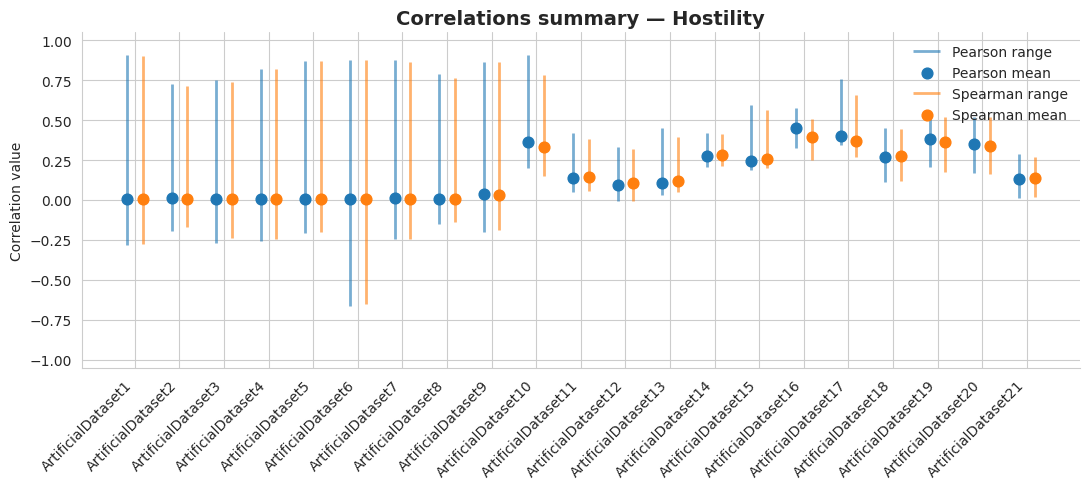

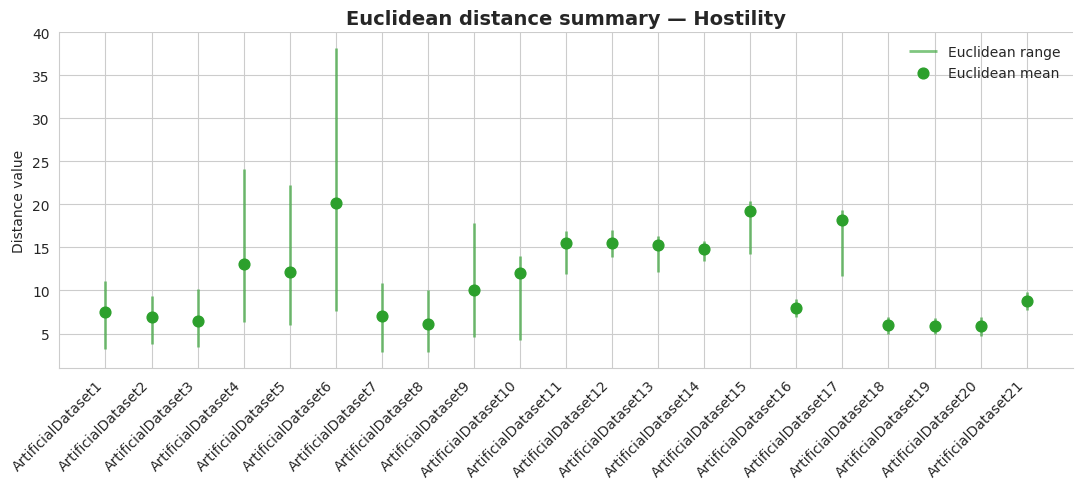

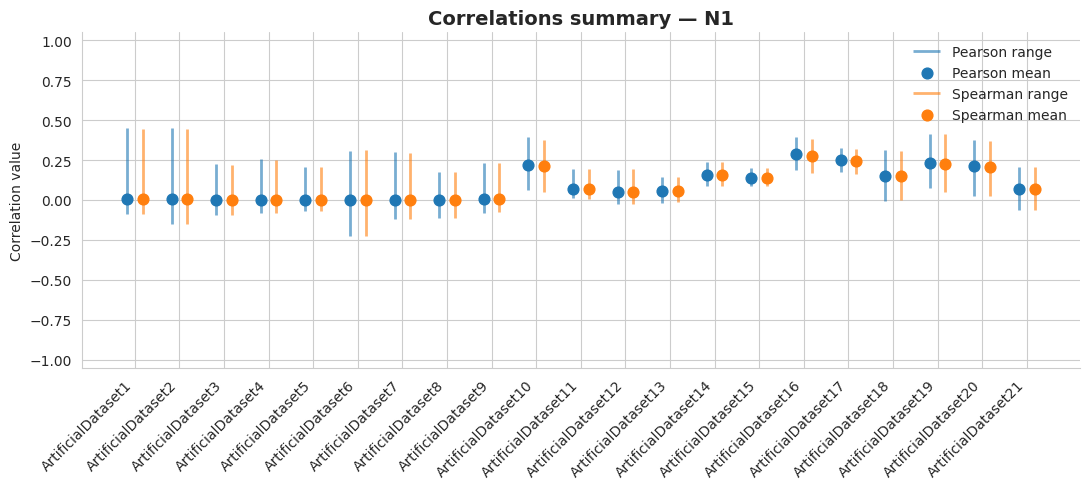

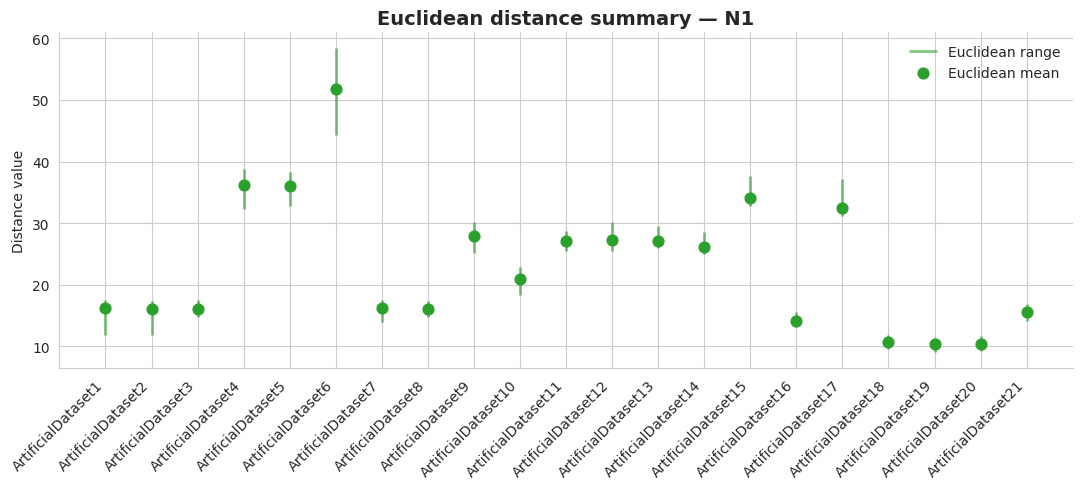

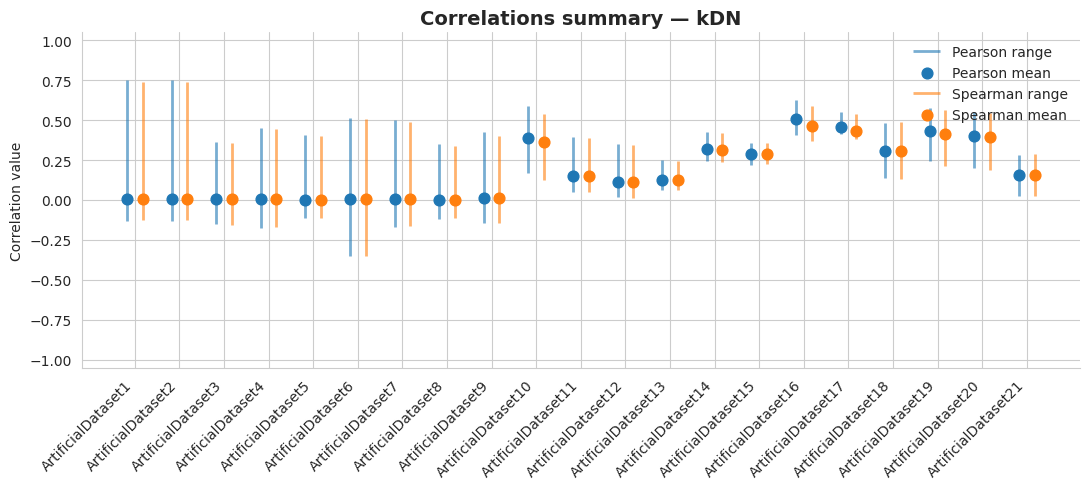

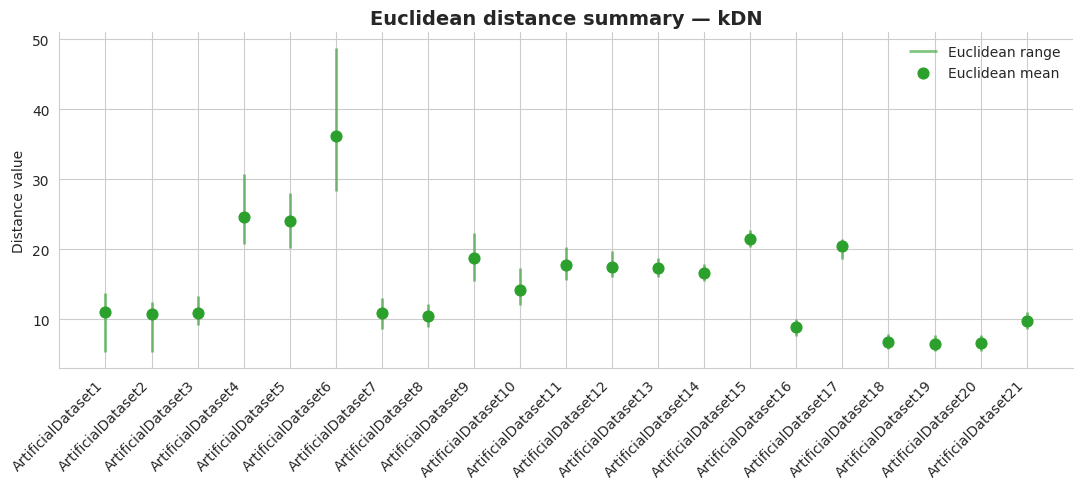

In [10]:
plot_summary_correlations(summary_df)


Realmente no llego a apreciar nada. No veo un patrón claro.

Al principio, numéricamente parecía que según los conjuntos de datos iban siendo mayores en tamaño, se notaban menos diferencias. Pero al ver este resumen más completo, creo que esa tendencia solo se aprecia con la hostilidad. Con N1 y kDN no queda tan clara esa tendencia.

Cosas que veo claras:
- La hostilidad es la medida que mayores correlaciones muestra y mayor rango de valores tanto para correlación como para distancia euclídea.
- N1 es claramente la que arroja valores más similares entre sí, va a costar mucho discernir solo con los valores que da.
- kDN se sitúa como un punto intermedio.

POR HACER:
- ANALIZAR DE UNO EN UNO LO QUE SE PUEDA
- HACER MISMO ESTUDIO PARA DATOS TAL CUAL, A VER CÓMO SE COMPORTAN CORRELACIONES Y DISTANCIAS
- ESTUDIAR RESULTADOS DE CLUSTERING, ELEGIR EL NÚMERO DE CLUSTERS DE FORMA AUTOMÁTICA
- FILTRAR AQUELLAS VARIABLES CON UNA CORRELACIÓN MAYOR (EN VALOR ABSOLUTO) A UN UMBRAL
- FILTRAR AQUELLAS VARIABLES CON UNA CORRELACIÓN MAYOR (EN VALOR ABSOLUTO) QUE UN CUARTIL
- ESTUDIAR QUÉ VARIABLES SON LAS QUE SE FILTRAN PARA EVALUARLO

### Estudio individualizado

Estudiamos ahora los resultados para algunos de los datasets de forma individual. No lo hacemos para todos porque tienen tantas variables que ya en los mapas de calor no se aprecia nada. Además, gracias a los gráficos previos ya sabemos que el rango de valores es muy bajito. Por otro lado, normalmente en los plots no cabe el nombre de todas las variables en la leyenda. Ahora esto no nos importa porque lo que buscamos es si realmente se detecta relación entre variables con las complejidades a nivel instancia.

In [11]:
dataset_files = ['Results_UnivariateRanking_CM/ArtificialDataset1_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset2_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset3_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset4_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset5_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset6_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset7_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset8_featuresComplexityInstances.csv',
                 'Results_UnivariateRanking_CM/ArtificialDataset9_featuresComplexityInstances.csv',
                'Results_UnivariateRanking_CM/ArtificialDataset10_featuresComplexityInstances.csv']

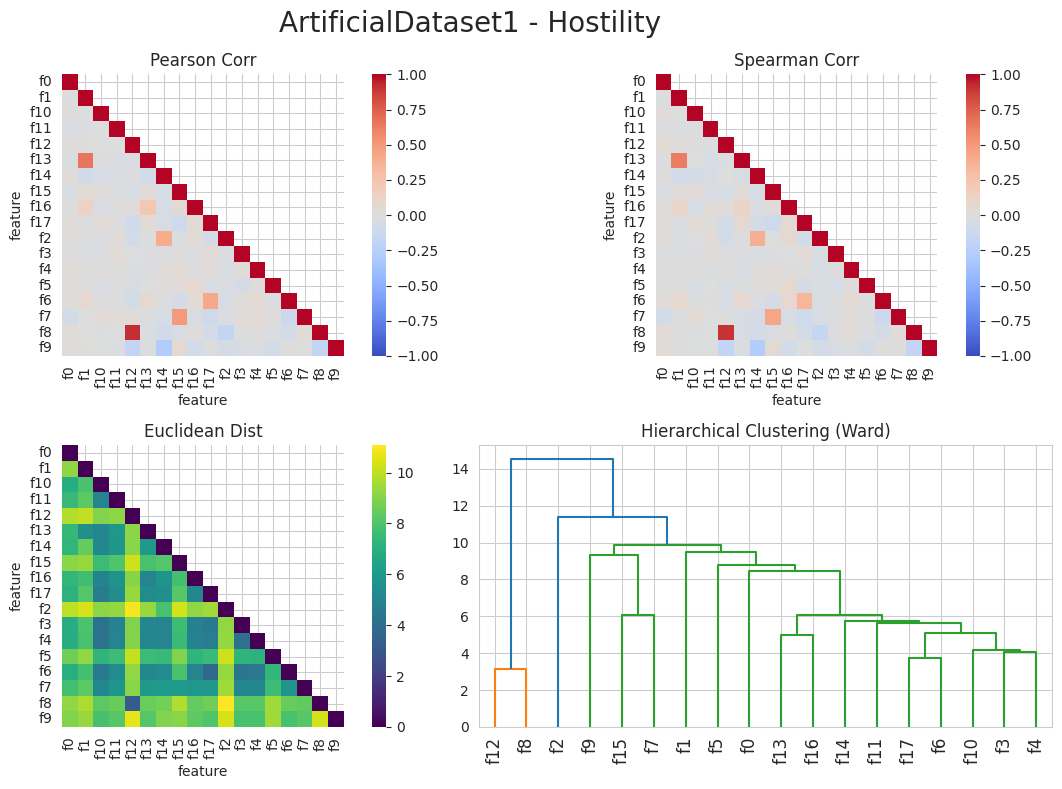

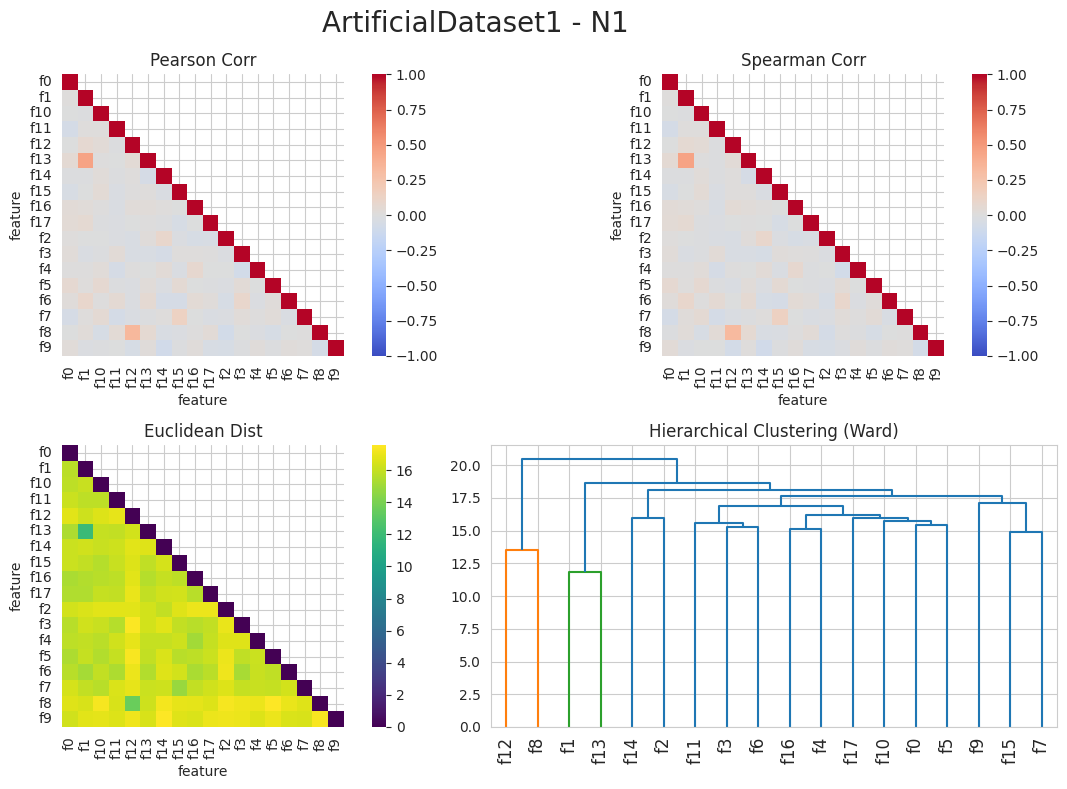

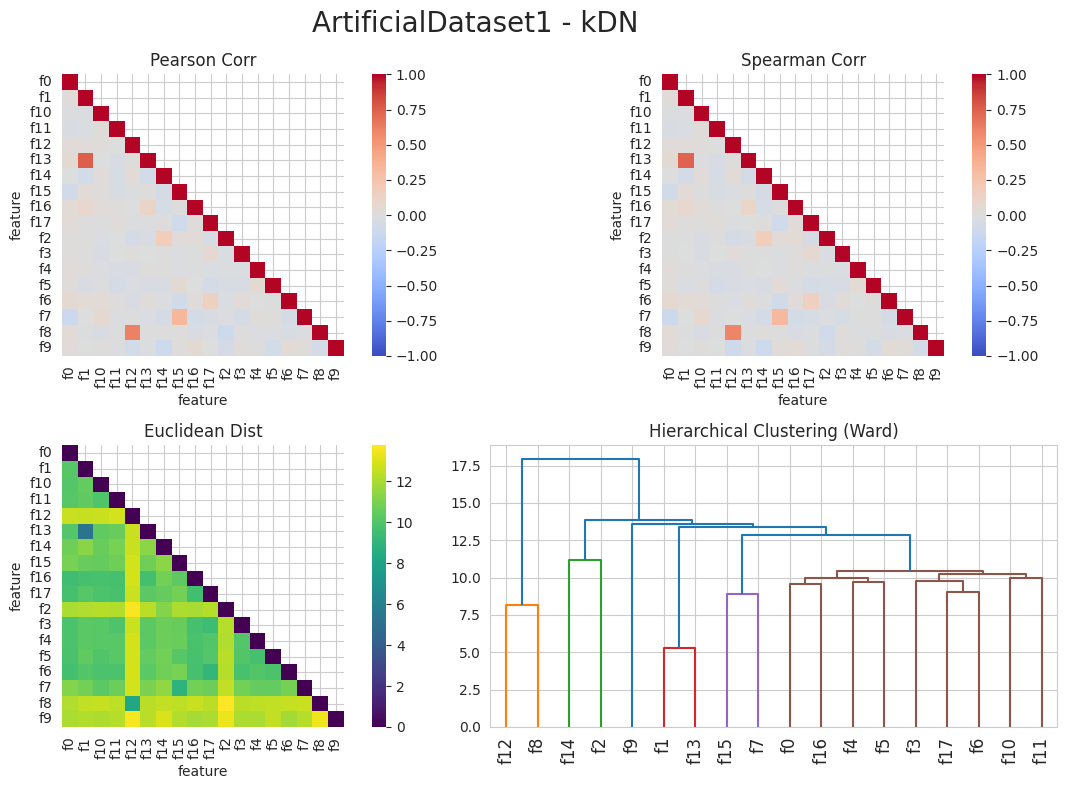

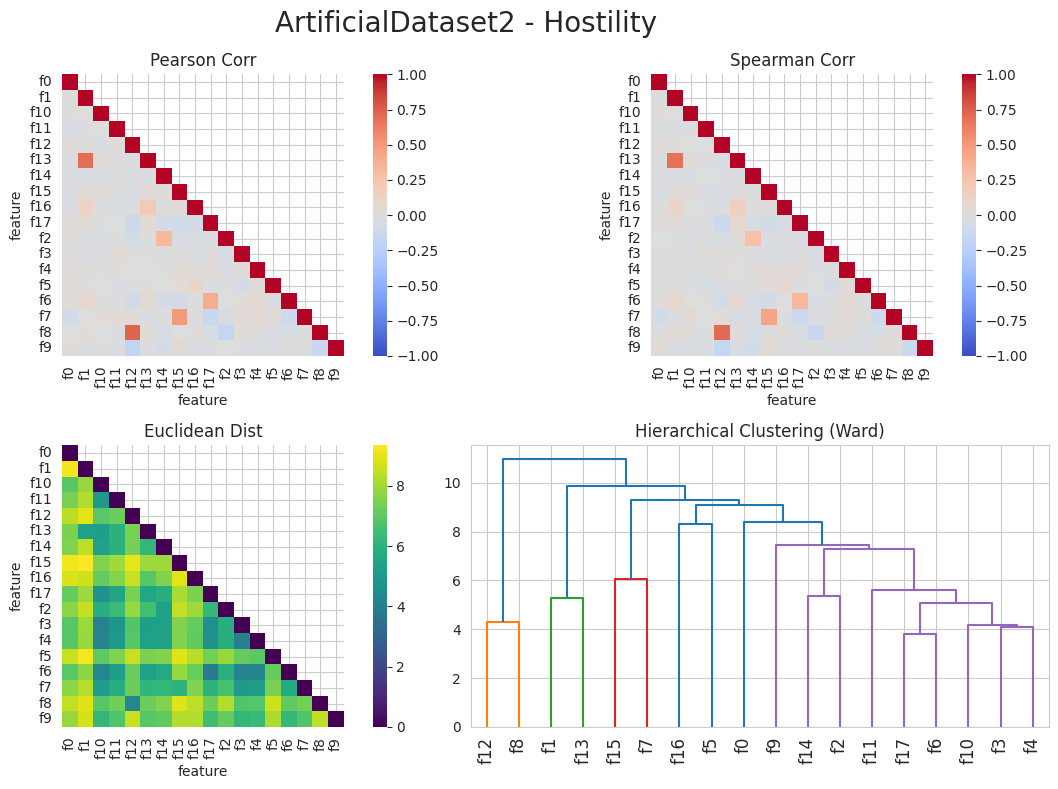

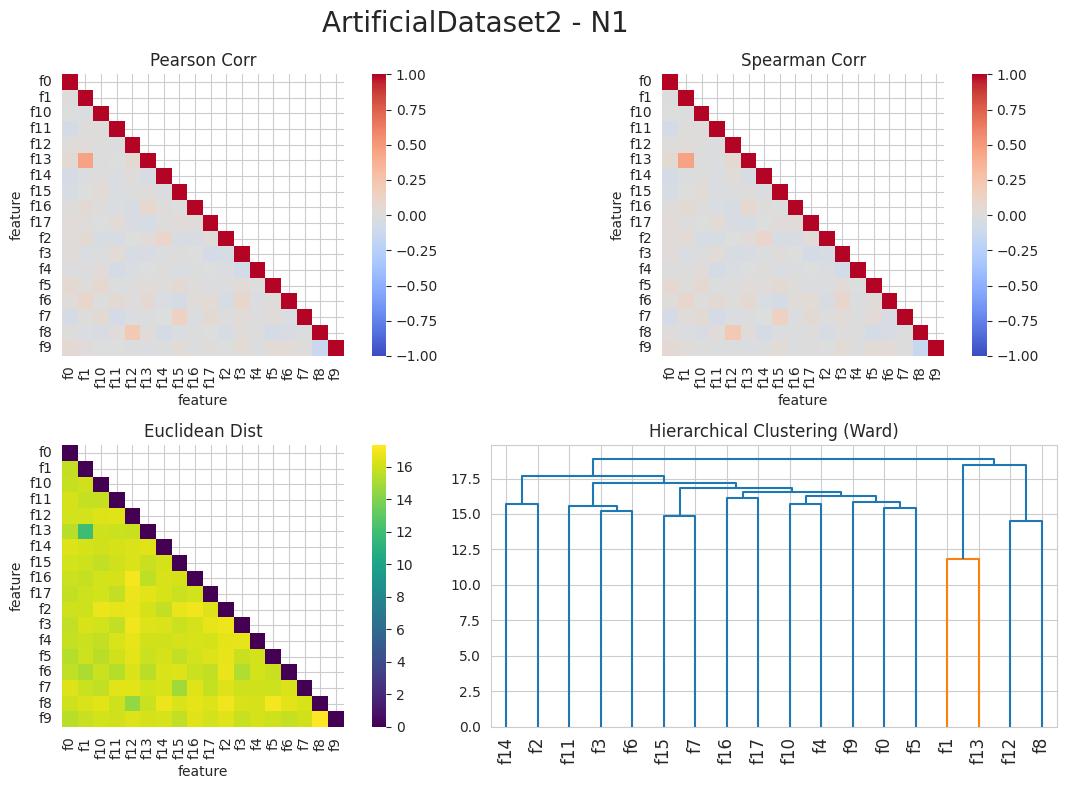

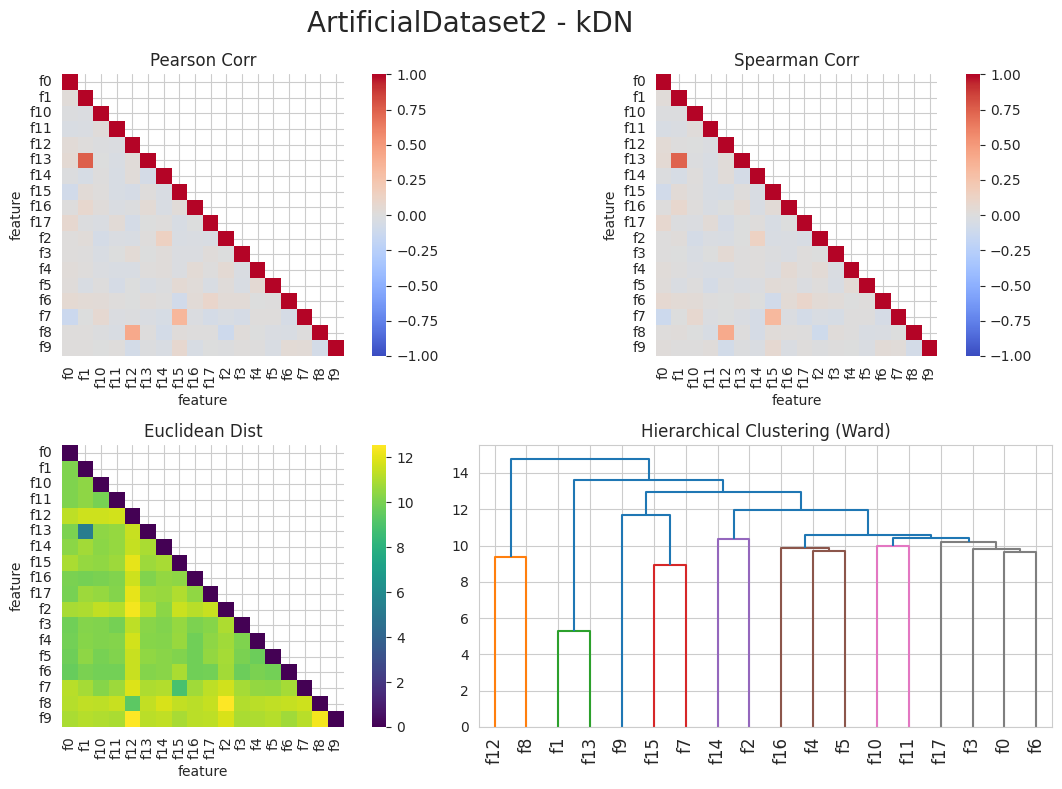

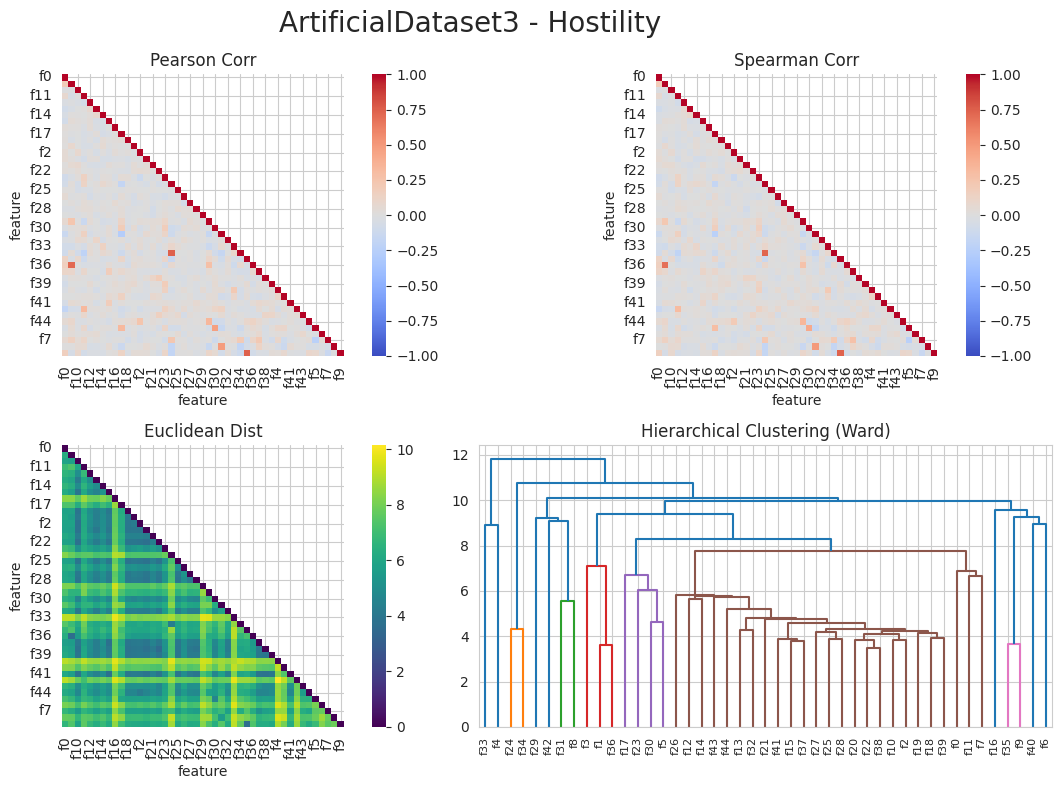

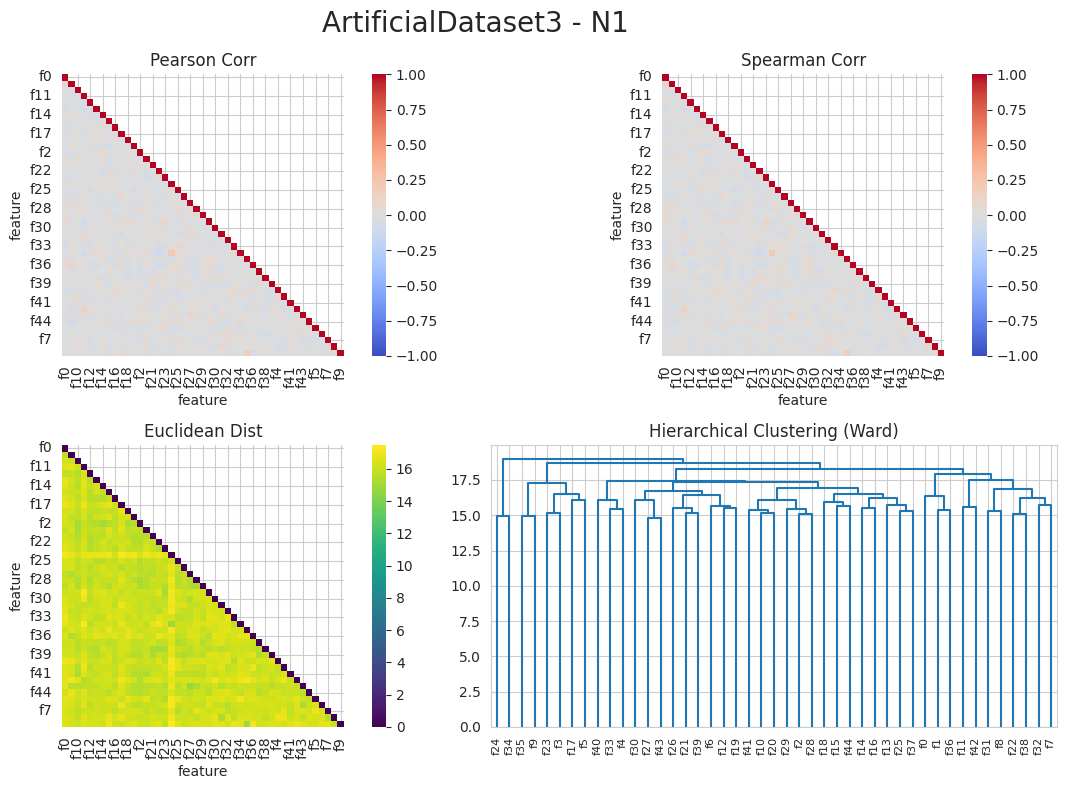

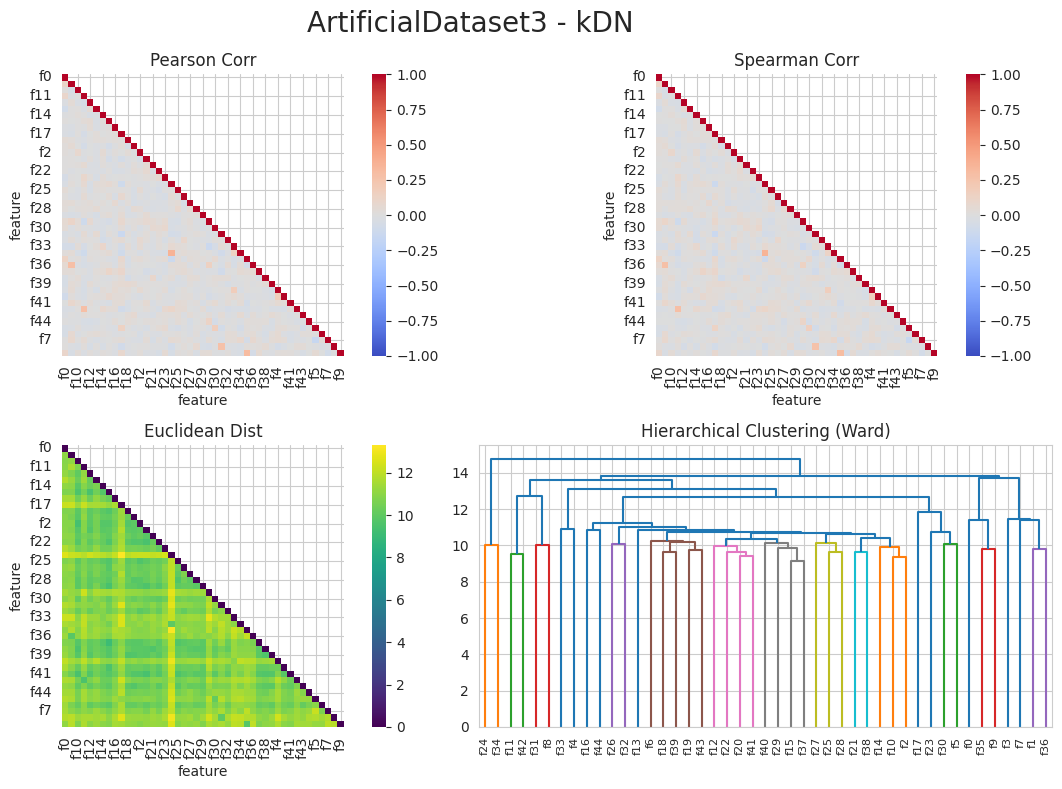

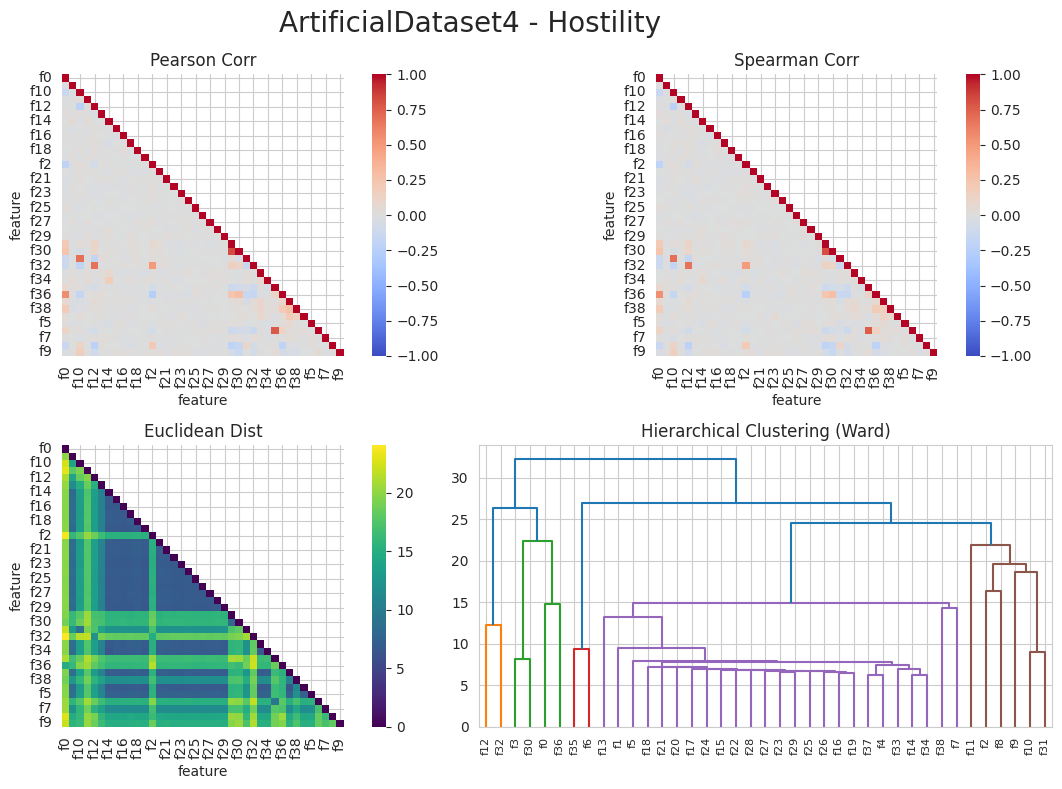

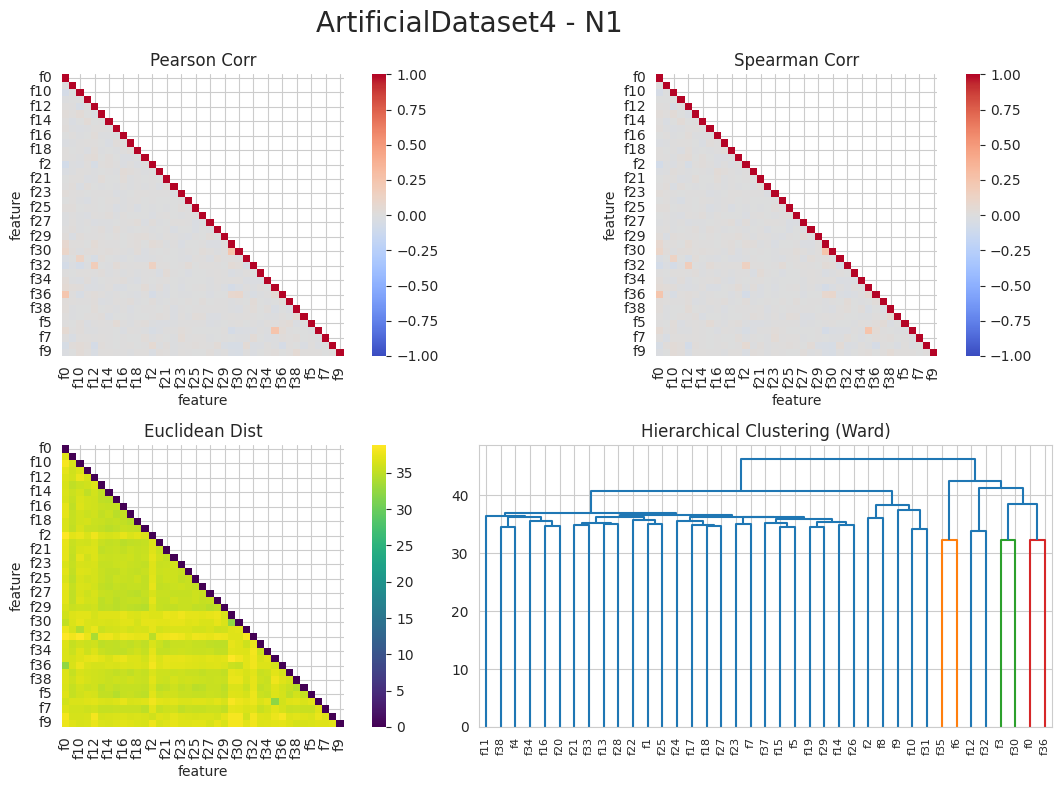

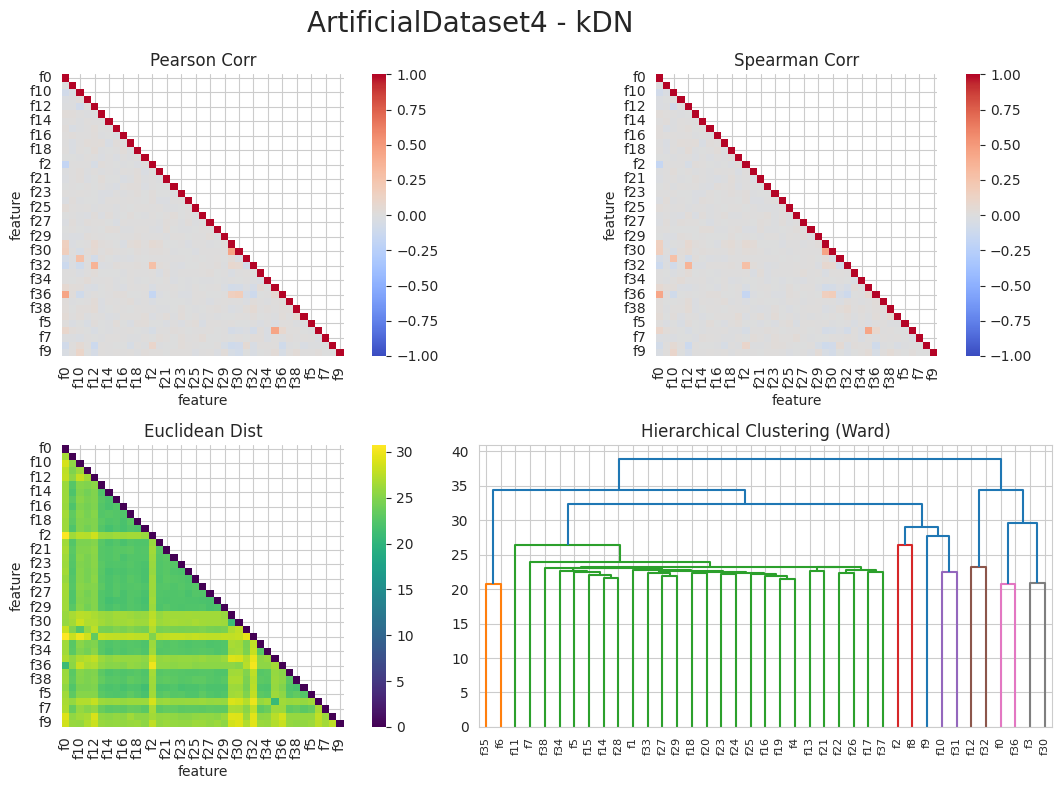

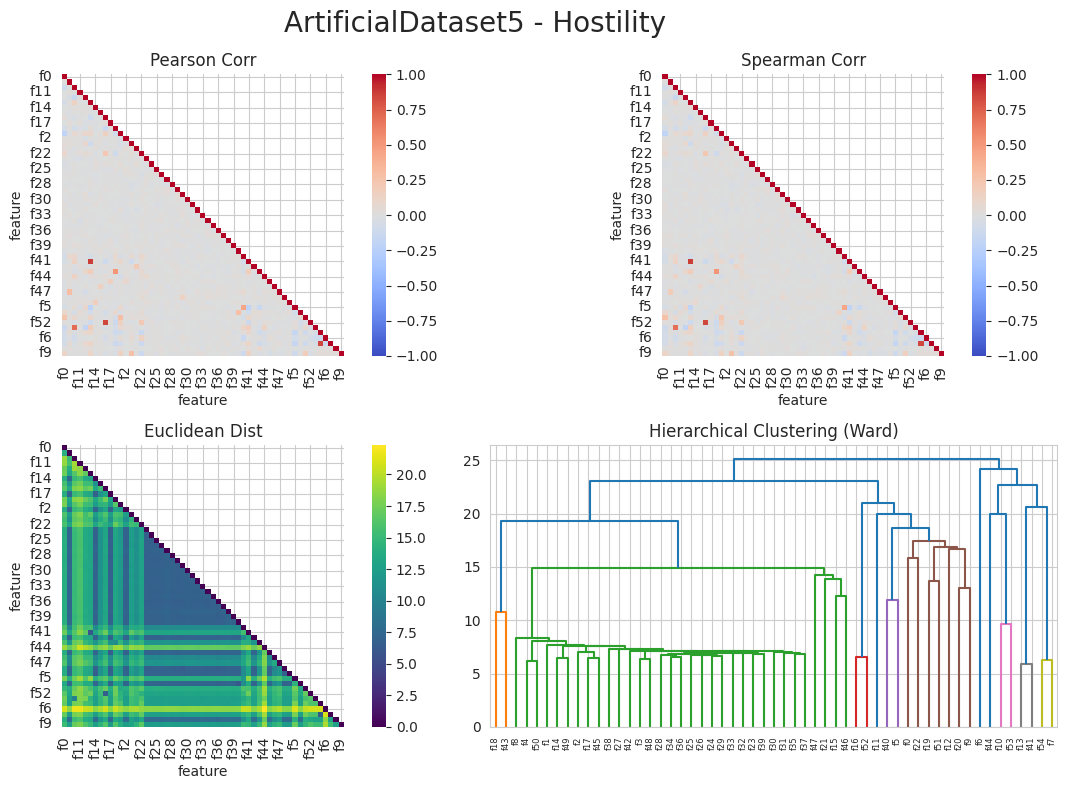

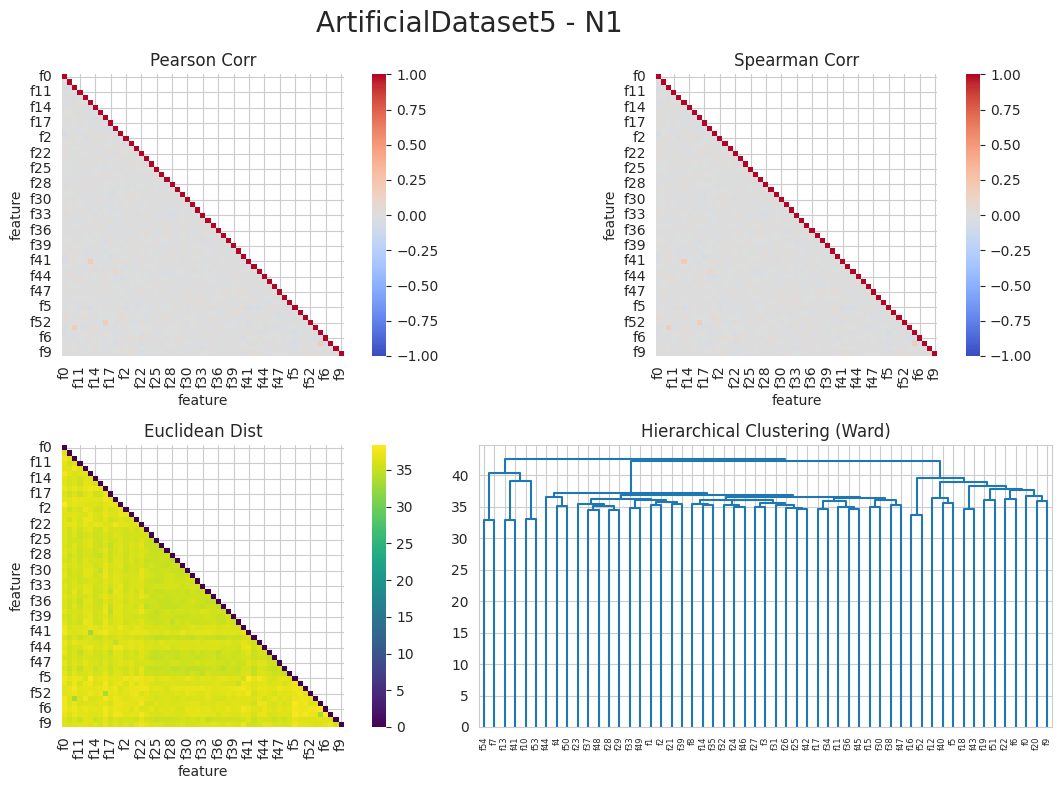

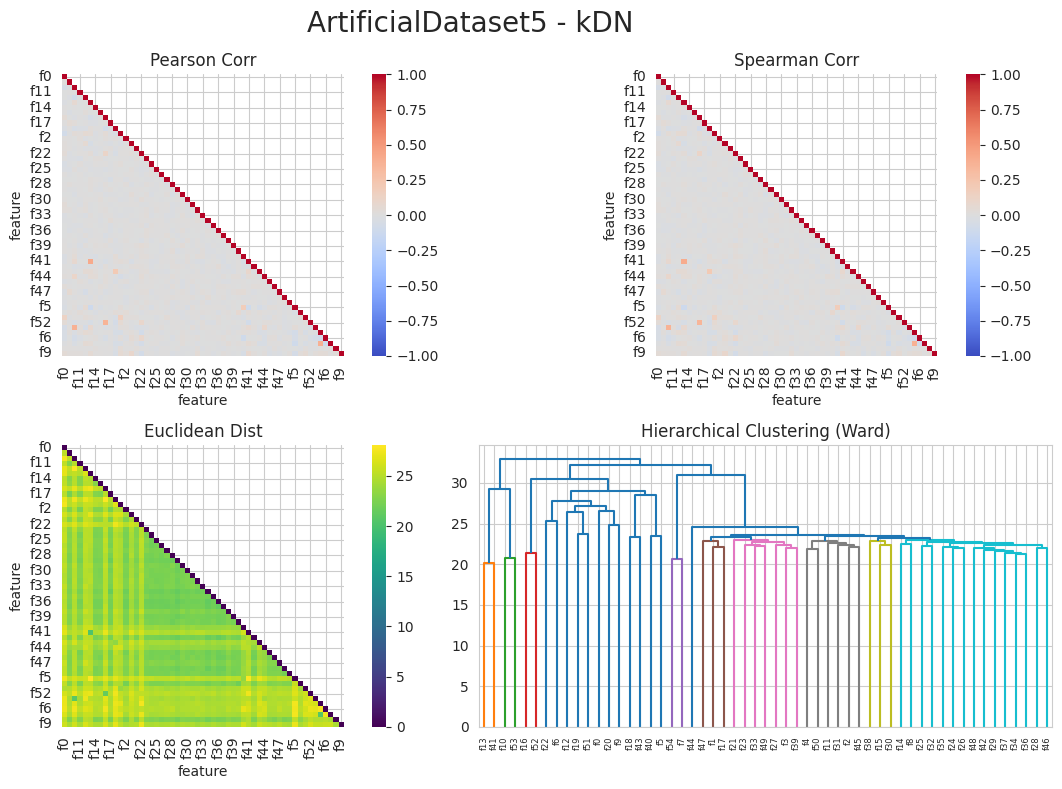

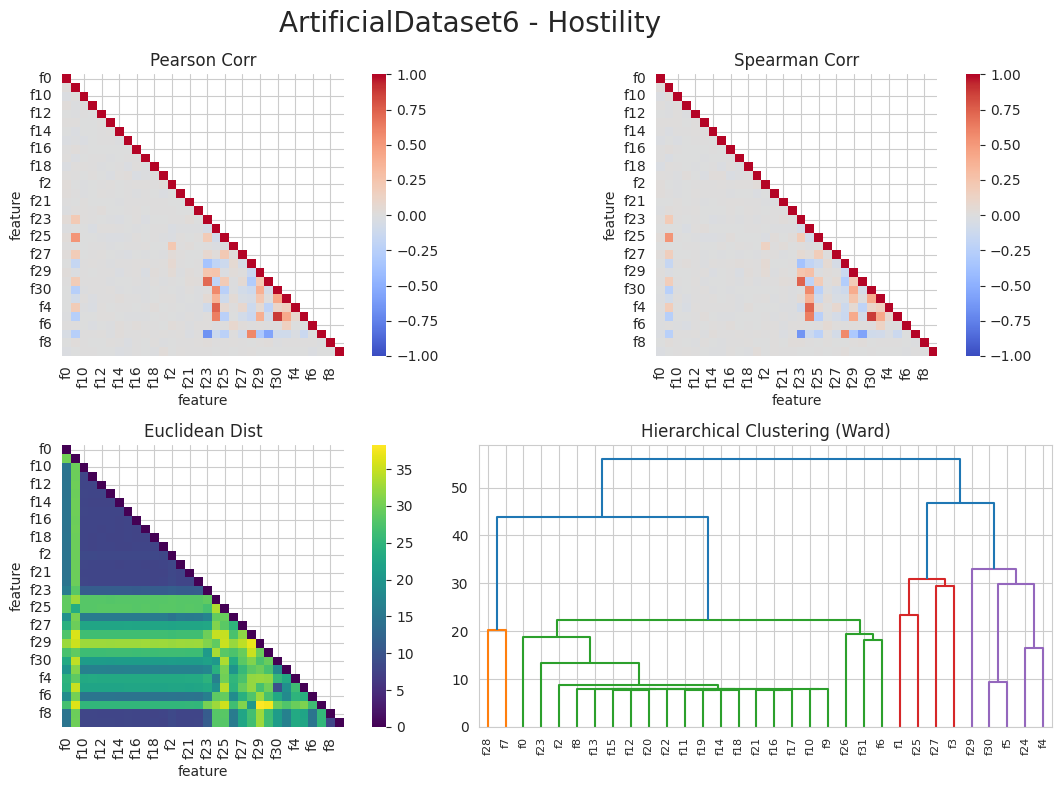

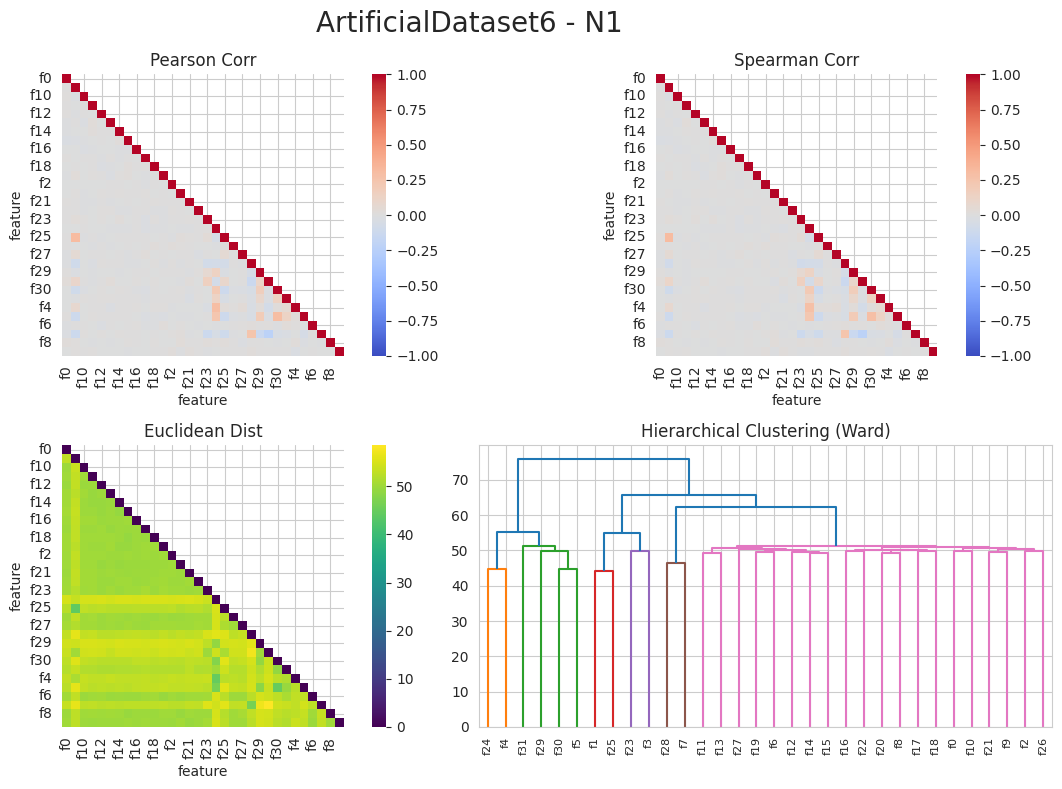

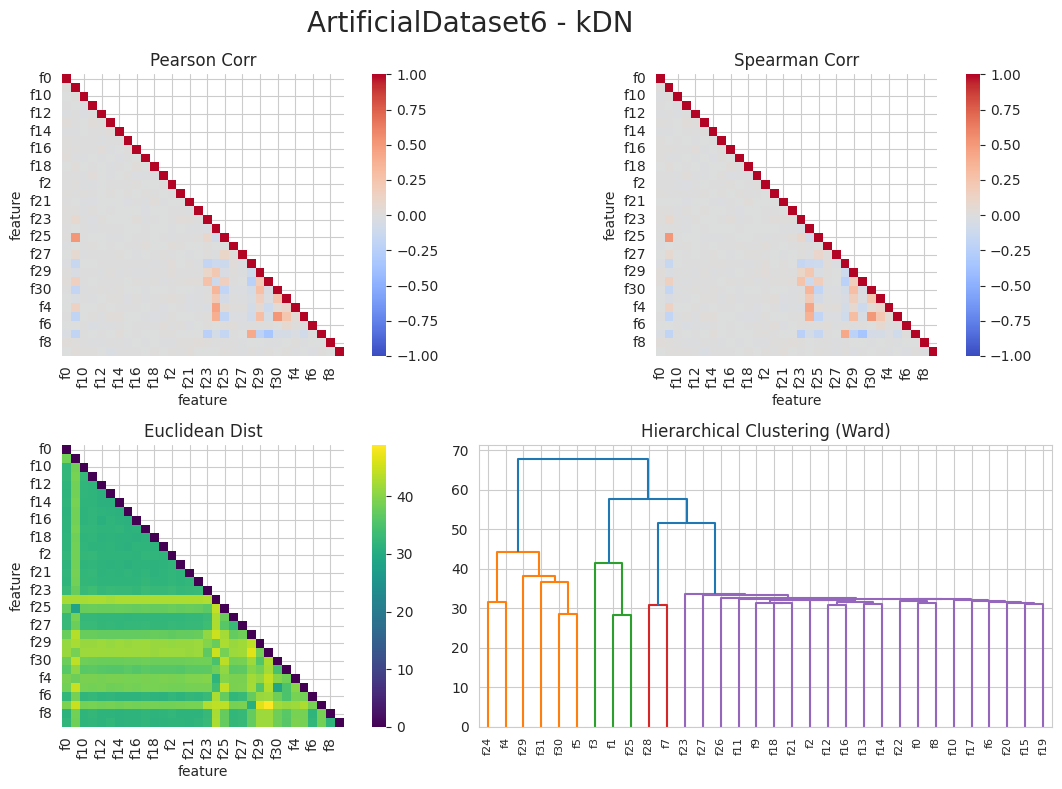

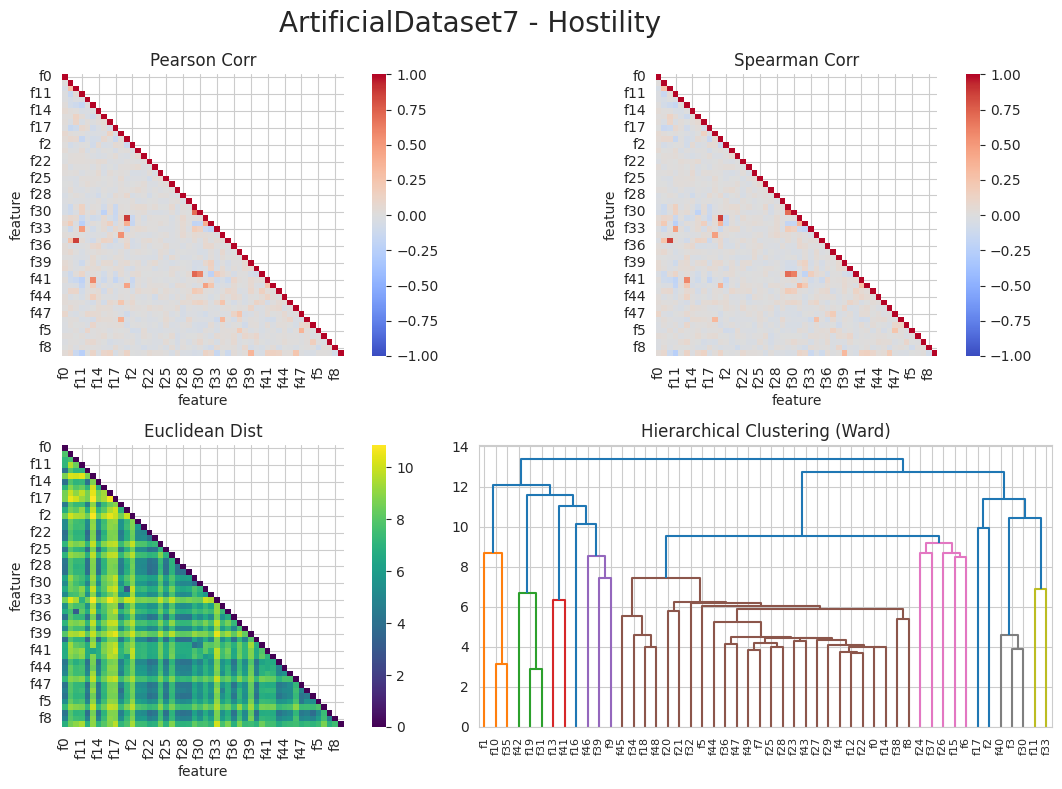

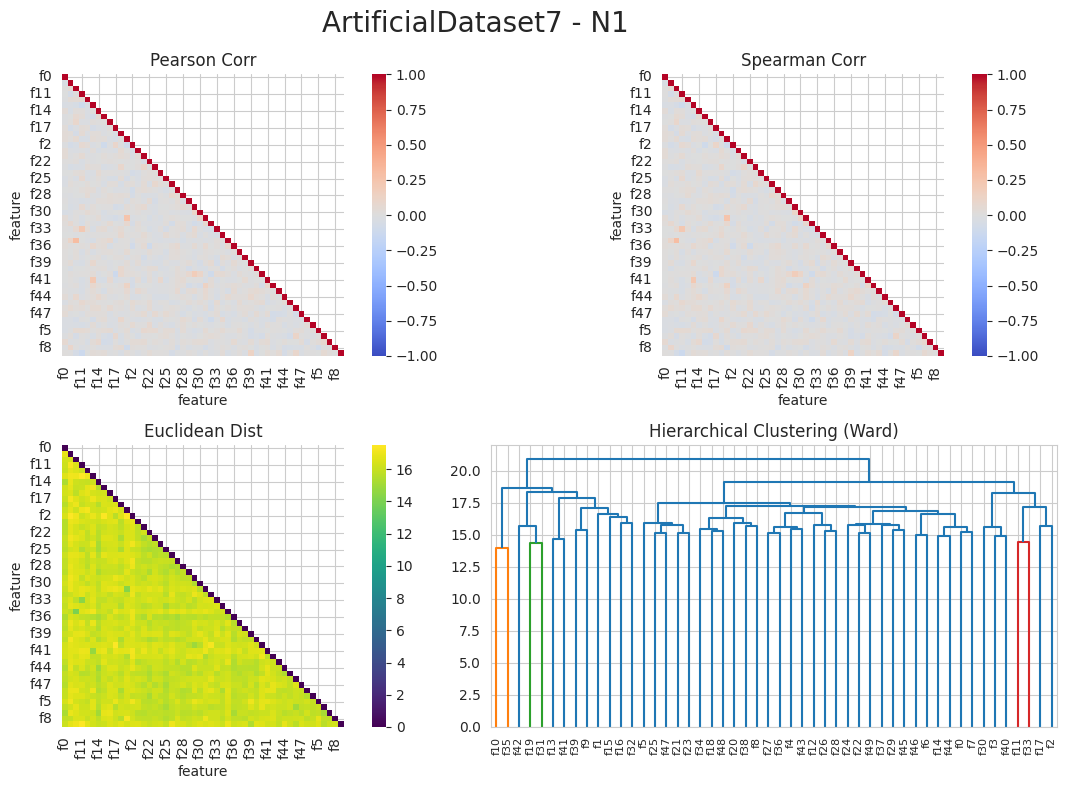

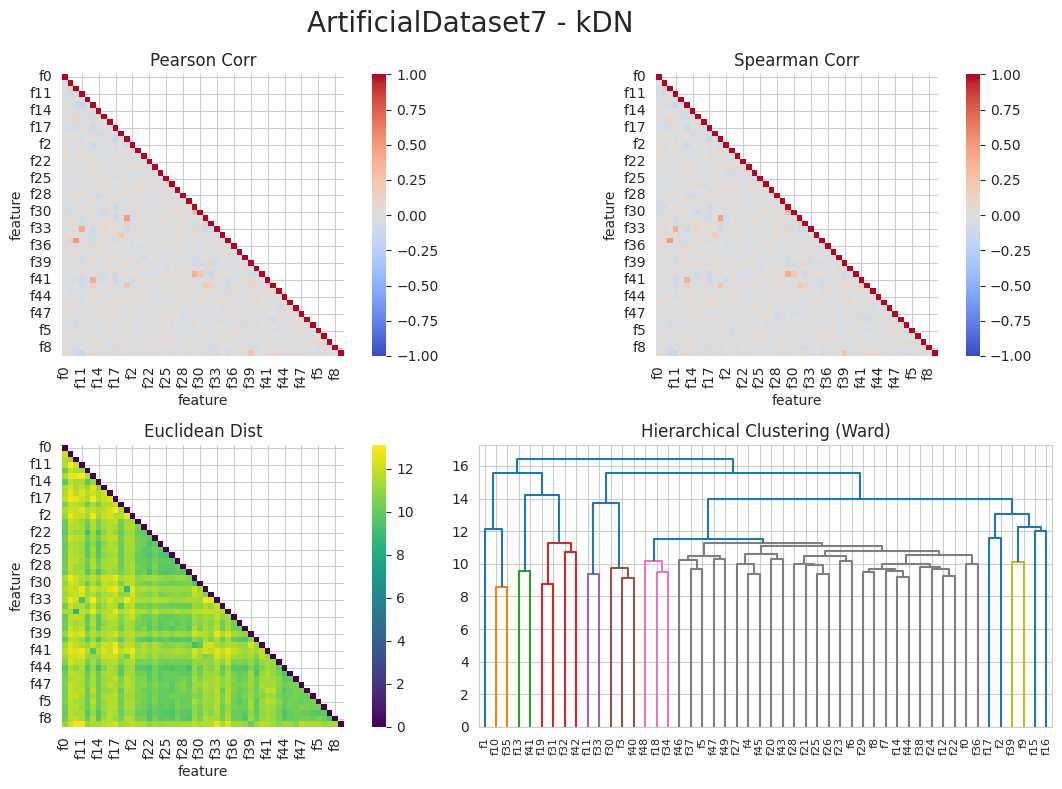

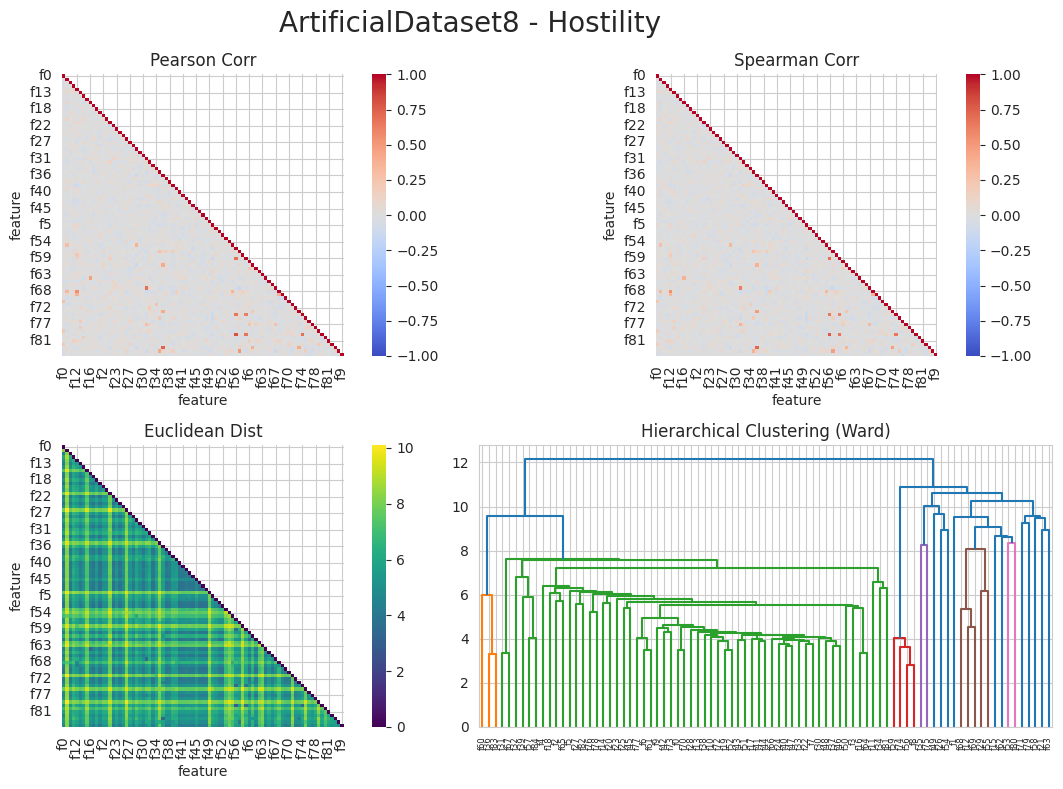

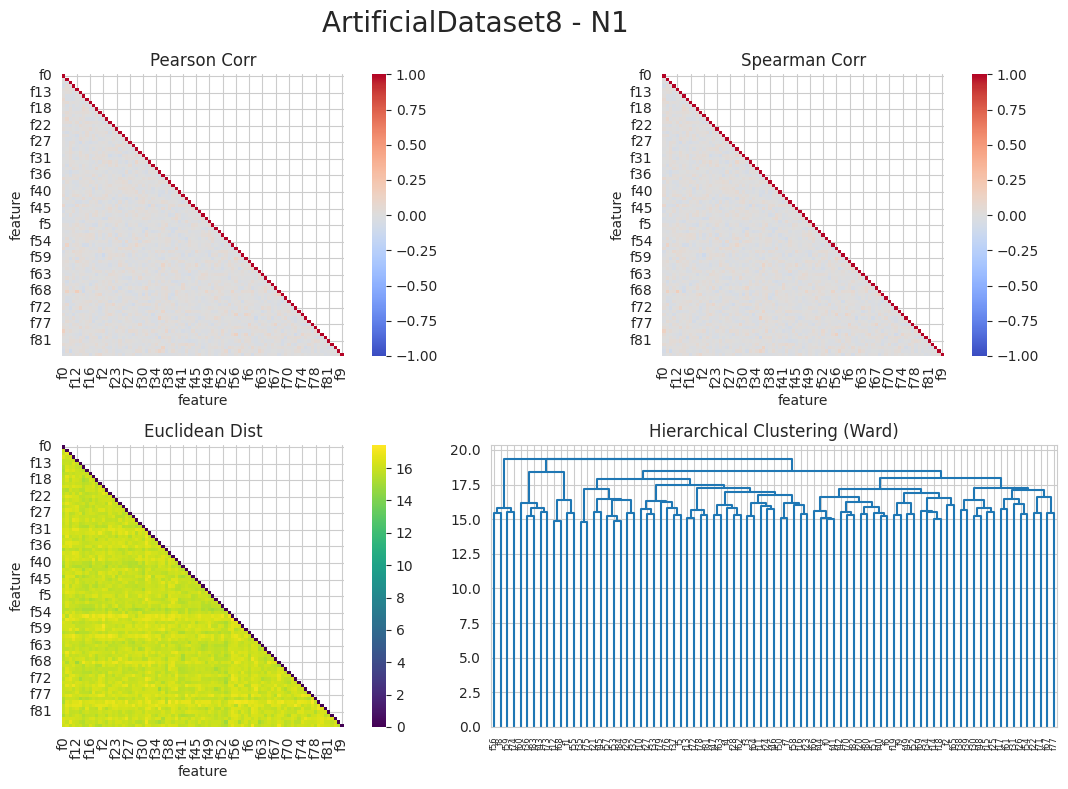

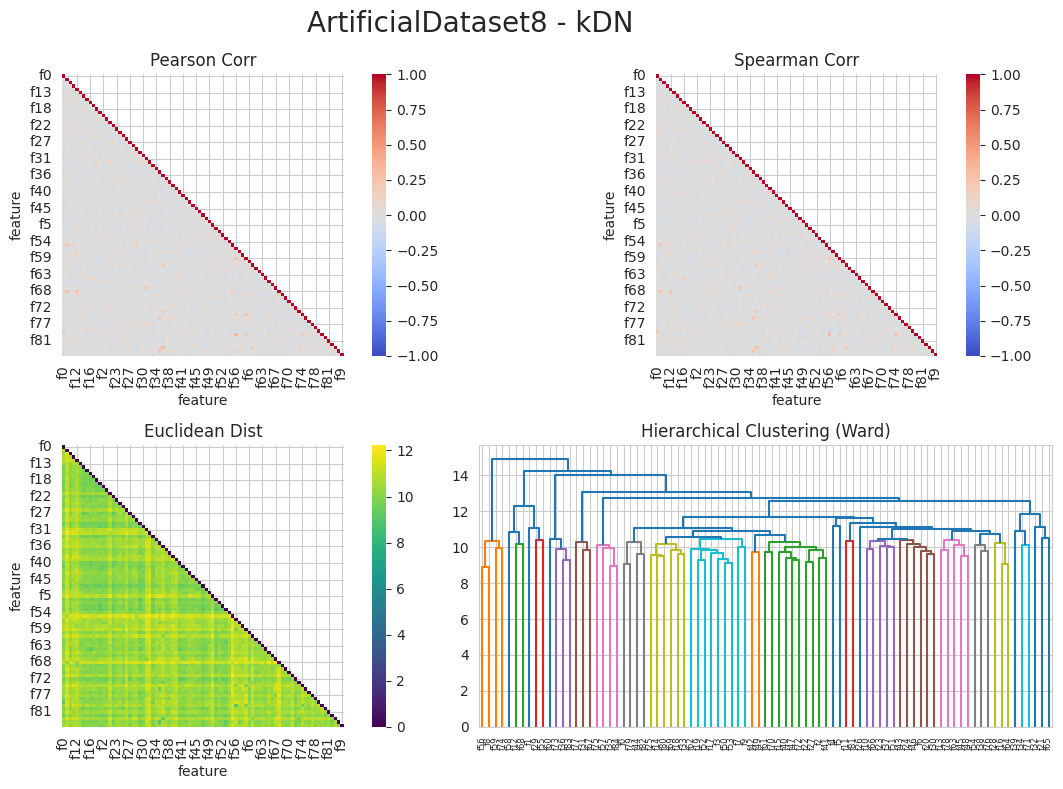

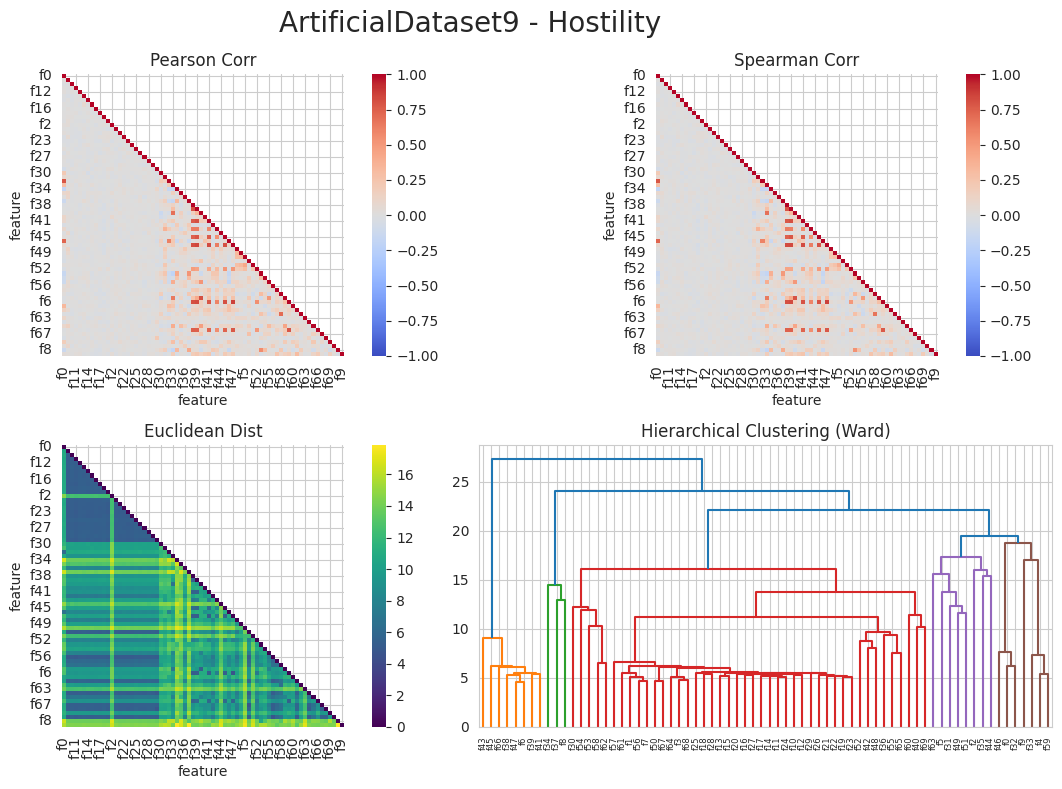

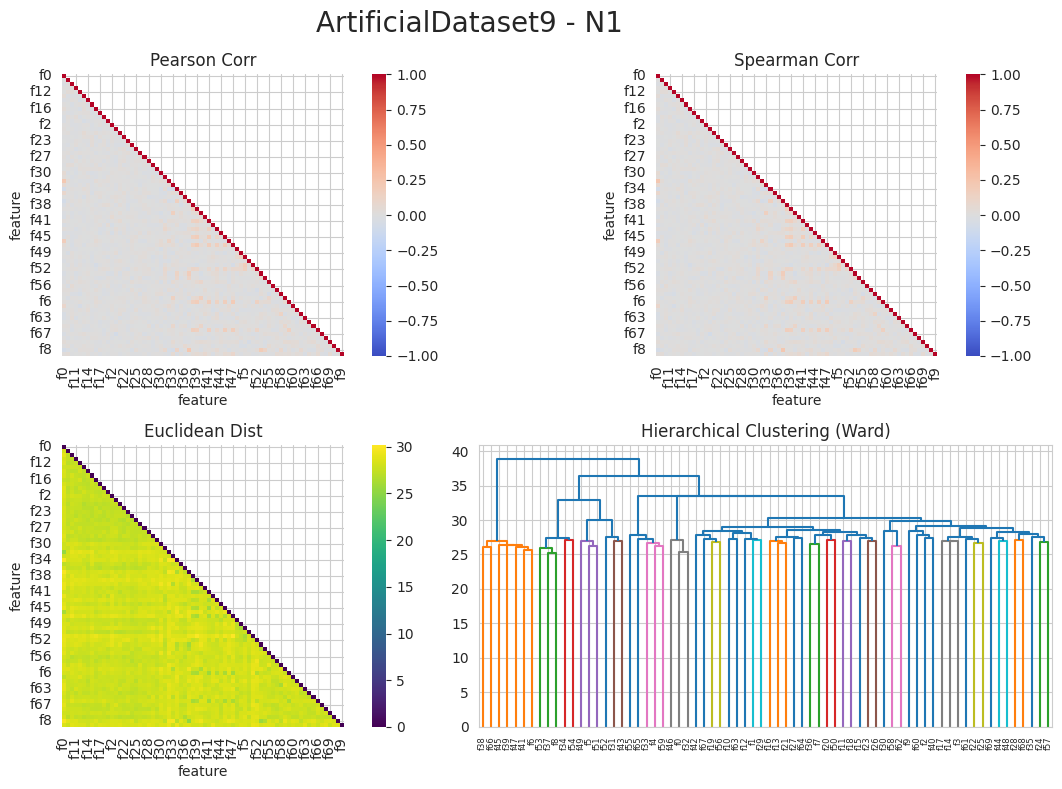

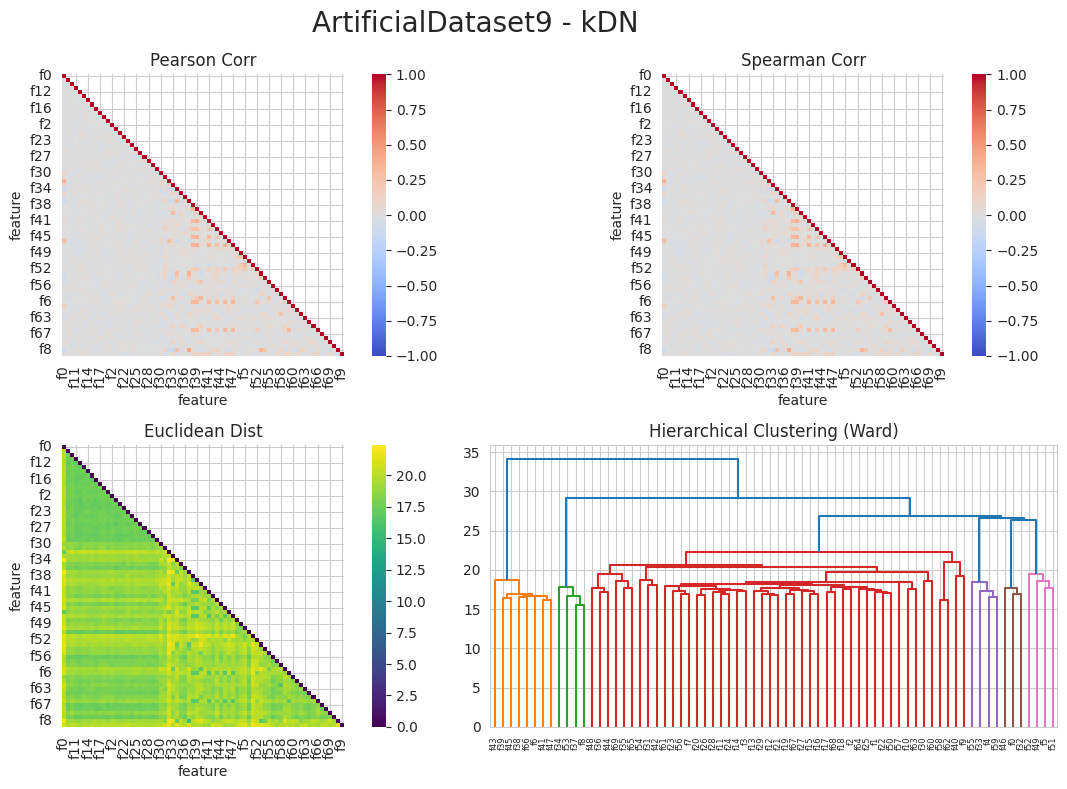

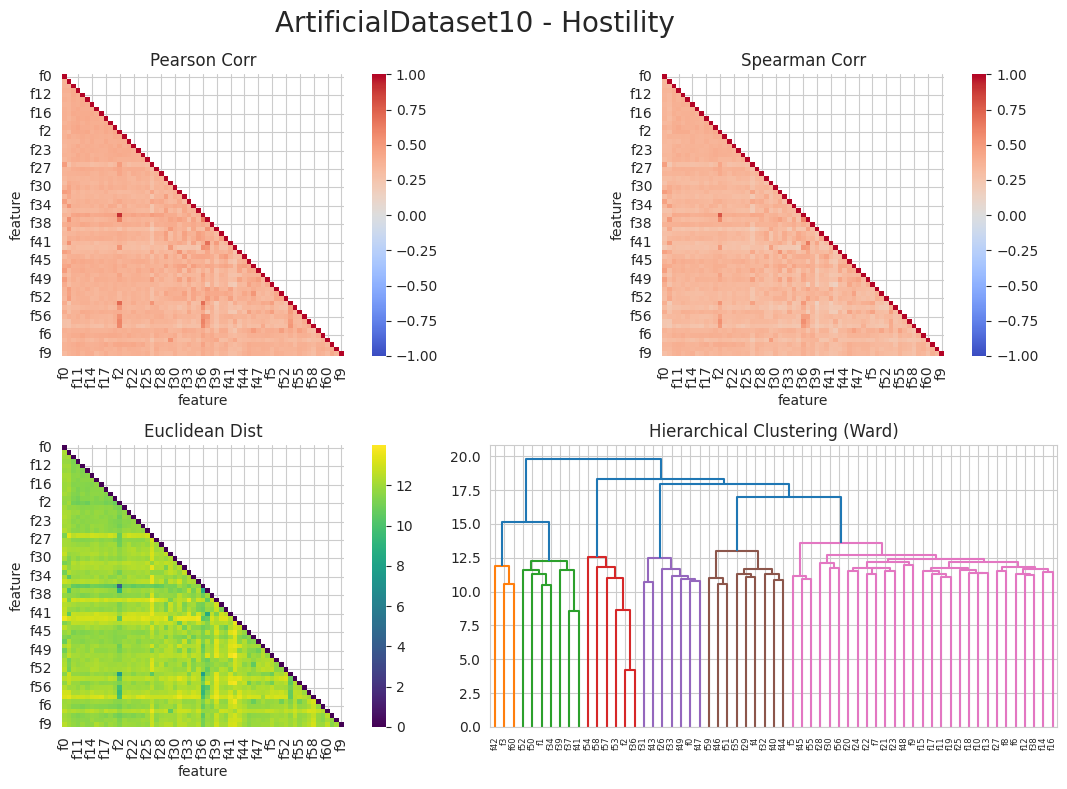

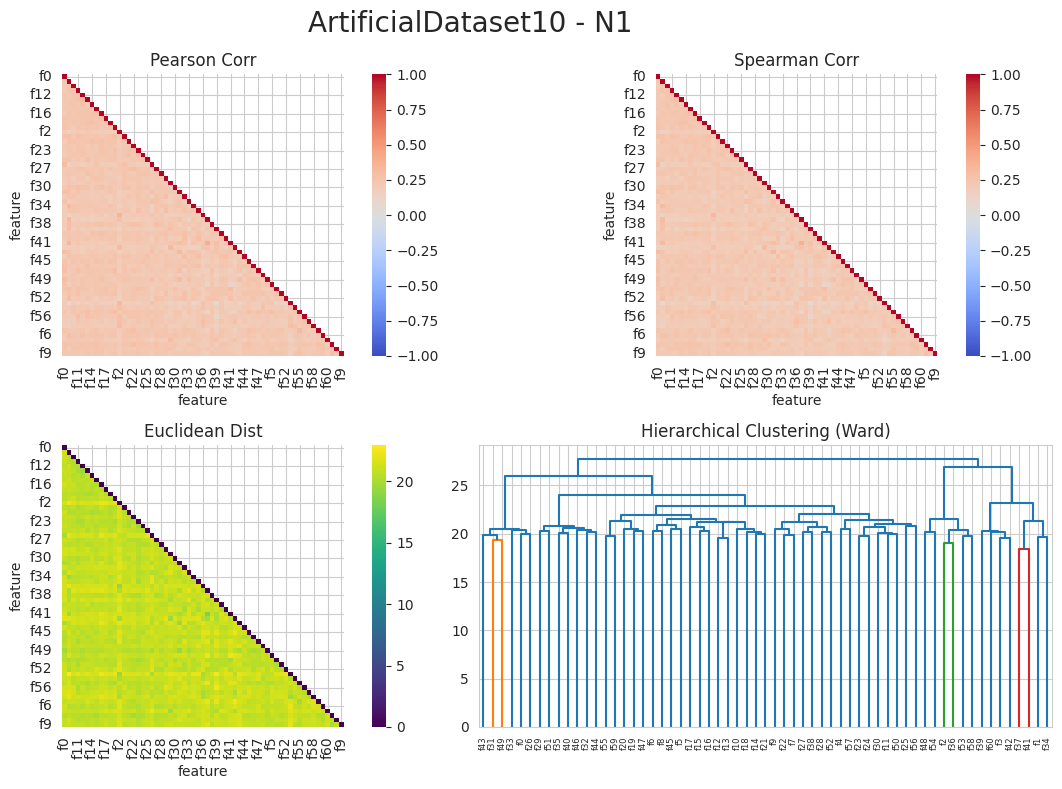

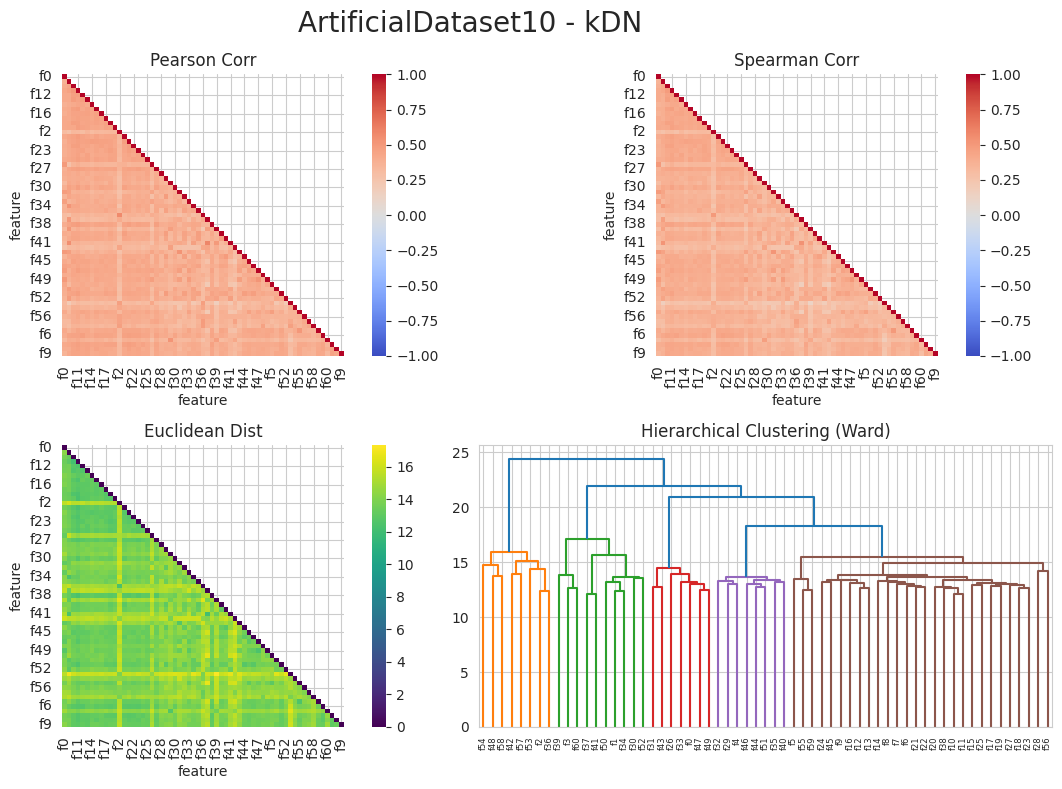

,dataset,measure,pearson_max,pearson_min,pearson_mean,pearson_median,pearson_std,spearman_max,spearman_min,spearman_mean,spearman_median,spearman_std,euclid_max,euclid_min,euclid_mean,euclid_median,euclid_std
0,ArtificialDataset1,Hostility,0.907902,-0.282526,0.007454,-0.006258,0.122935,0.900539,-0.278598,0.004647,-0.006265,0.117590,11.069503,3.162018,7.485027,7.850510,1.847186
1,ArtificialDataset1,N1,0.448381,-0.090766,0.005319,-0.001197,0.058285,0.446141,-0.086016,0.005057,-0.002129,0.057721,17.549929,11.863811,16.237640,16.232683,0.700729
2,ArtificialDataset1,kDN,0.751222,-0.129386,0.004608,-0.002061,0.094220,0.736380,-0.123296,0.004720,-0.002615,0.092341,13.753545,5.280152,11.093380,10.803703,1.285690
3,ArtificialDataset2,Hostility,0.726764,-0.193159,0.011141,-0.002945,0.109697,0.713162,-0.171043,0.008045,-0.007046,0.102681,9.340995,3.818950,6.961848,7.149602,1.317034
4,ArtificialDataset2,N1,0.448381,-0.147692,0.005674,0.001477,0.055239,0.446141,-0.148439,0.005706,0.001825,0.055072,17.306068,11.863811,16.104286,16.124515,0.539327
5,ArtificialDataset2,kDN,0.751222,-0.129386,0.005486,-0.001317,0.084308,0.736380,-0.123296,0.005053,-0.002015,0.082389,12.537942,5.280152,10.696006,10.710742,0.799450
6,ArtificialDataset3,Hostility,0.749055,-0.268684,0.006599,0.000228,0.074553,0.737531,-0.235967,0.005771,-0.000116,0.071464,10.146274,3.471729,6.457165,6.332416,1.496687
7,ArtificialDataset3,N1,0.224171,-0.095081,0.000671,-0.000908,0.036029,0.216602,-0.096531,0.000630,-0.001074,0.035918,17.464249,14.773287,16.162866,16.156354,0.421399
8,ArtificialDataset3,kDN,0.362165,-0.151104,0.003048,-0.000084,0.044035,0.355190,-0.154253,0.002890,-0.000167,0.043699,13.289093,9.134550,10.852795,10.874741,0.689926
9,ArtificialDataset4,Hostility,0.821890,-0.258545,0.006270,0.001098,0.077221,0.818252,-0.244135,0.005071,0.000330,0.075236,24.068762,6.295068,13.053582,14.229062,4.684128


In [12]:
analyze_variable_relationships(dataset_files,show_plots=True)

Estos resultados revelan la misma información que los globales:
- N1 es la medida que da valores más similares. Los mapas de calor son de un color bastante homogéneo y en los dendrogramas se aprecia que todo se junta más o menos al mismo nivel y muy arriba. Con la información que da N1 no se encuentra una estructura cluster clara.
- Hostility es la que muestra patrones más claros. Sí se pueden distinguir variables más relacionadas (mayor correlación, menor distancia euclídea) y alguna estructura cluster de variables que parece que sí se agruparían con mayor seguridad.
- kDN está a caballo entre ambas, aunque se asemeja ligeramente más a la hostilidad porque se pueden sacar más conclusiones que con N1 (que no se puede extraer ninguna).

Otra cosa interesante es que la mayor parte de las correlaciones salen en rojito, es decir, son positivas. También podrían salir correlaciones negativas si tuviéramos variables completamente contrarias pero eso es raro, es una situación muy excepcional. Puede que haya variables cuyas complejidades no vayan a la par, pero de ahí a tener una correlación negativa fuerte va un trecho.


## Mismo estudio con datos originales

In [13]:
# Datos originales
X1, y1, _ = generate_synthetic_dataset(n_samples=1000,n_informative=10,n_noise=2,
                                         n_redundant_linear=4,n_redundant_nonlinear=2,
                                        flip_y=0, class_sep = 1, n_clusters_per_class=1 , weights=[0.5],
                                                     random_state=0,noise_std=0.01)
X2, y2, _ = generate_synthetic_dataset(n_samples=1000,n_informative=10,n_noise=2,
                                         n_redundant_linear=4,n_redundant_nonlinear=2,
                                    flip_y=0, class_sep = 0.6, n_clusters_per_class=1 , weights=[0.5],
                                                     random_state=0,noise_std=0.01)

X3, y3, _ = generate_synthetic_dataset(n_samples=1000,n_informative=25,n_noise=5,
                                         n_redundant_linear=7,n_redundant_nonlinear=8,
                                         flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=0,noise_std=0.05)

X4, y4, _ = generate_synthetic_dataset(n_samples=5000,n_informative=15,n_noise=15,
                                         n_redundant_linear=4,n_redundant_nonlinear=5,
                                        flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=10,noise_std=0.01)

X5, y5, _ = generate_synthetic_dataset(n_samples=5000,n_informative=25,n_noise=15,
                                         n_redundant_linear=8,n_redundant_nonlinear=7,
                                     flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=10,noise_std=0.05)

X6, y6, _ = generate_synthetic_dataset(n_samples=10000,n_informative=8,n_noise=15,
                                         n_redundant_linear=4,n_redundant_nonlinear=5,
                                         flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=589,noise_std=0.01)

X7, y7, _ = generate_synthetic_dataset(n_samples=1000,n_informative=20,n_noise=10,
                                         n_redundant_linear=10,n_redundant_nonlinear=10,
                                        flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=589,noise_std=0.05)

X8, y8, _ = generate_synthetic_dataset(n_samples=1000,n_informative=40,n_noise=15,
                                         n_redundant_linear=15,n_redundant_nonlinear=15,
                                        flip_y=0, class_sep=1, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=86785,noise_std=0.1)

X9, y9, _ = generate_synthetic_dataset(n_samples=3000,n_informative=10,n_noise=20,
                                         n_redundant_linear=20,n_redundant_nonlinear=20,
                                        flip_y=0, class_sep=0.7, n_clusters_per_class=1, weights=[0.5],
                                                     random_state=959,noise_std=0.3)

X10, y10, _ = generate_synthetic_dataset(n_samples=2000,n_informative=6,n_noise=20,
                                         n_redundant_linear=20,n_redundant_nonlinear=15,
                                        flip_y=0, class_sep=0.8, n_clusters_per_class=2, weights=[0.3],
                                                     random_state=959,noise_std=0.3)

X11, y11, _ = generate_synthetic_dataset(n_samples=3000,n_informative=20,n_noise=20,
                                         n_redundant_linear=20,n_redundant_nonlinear=15,
                                        flip_y=0, class_sep=0.6, n_clusters_per_class=1, weights=[0.4],
                                                     random_state=959,noise_std=0.1)

X12, y12, _ = generate_synthetic_dataset(n_samples=3000,n_informative=25,n_noise=30,
                                         n_redundant_linear=30,n_redundant_nonlinear=30,
                                        flip_y=0.2, class_sep=0.9, n_clusters_per_class=1, weights=[0.4],
                                                     random_state=987,noise_std=0.5)

X13, y13, _ = generate_synthetic_dataset(n_samples=3000,n_informative=25,n_noise=30,
                                         n_redundant_linear=30,n_redundant_nonlinear=30,
                                        flip_y=0.2, class_sep=0.6, n_clusters_per_class=2, weights=[0.4],
                                                     random_state=95,noise_std=0.5)

X14, y14, _ = generate_synthetic_dataset(n_samples=3000,n_informative=30,n_noise=40,
                                         n_redundant_linear=30,n_redundant_nonlinear=40,
                                        flip_y=0.2, class_sep=0.6, n_clusters_per_class=2, weights=[0.3],
                                                     random_state=95,noise_std=0.5)

X15, y15, _ = generate_synthetic_dataset(n_samples=5000,n_informative=40,n_noise=40,
                                         n_redundant_linear=30,n_redundant_nonlinear=40,
                                        flip_y=0.3, class_sep=0.4, n_clusters_per_class=1, weights=[0.3],
                                                     random_state=78,noise_std=0.1)

X16, y16, _ = generate_synthetic_dataset(n_samples=1000,n_informative=50,n_noise=40,
                                         n_redundant_linear=30,n_redundant_nonlinear=40,
                                        flip_y=0.3, class_sep=0.4, n_clusters_per_class=1, weights=[0.2],
                                                     random_state=756,noise_std=0.5)

X17, y17, _ = generate_synthetic_dataset(n_samples=5000,n_informative=70,n_noise=40,
                                         n_redundant_linear=40,n_redundant_nonlinear=40,
                                        flip_y=0.3, class_sep=0.6, n_clusters_per_class=2, weights=[0.2],
                                                     random_state=756,noise_std=0.5)

X18, y18, _ = generate_synthetic_dataset(n_samples=500,n_informative=70,n_noise=40,
                                         n_redundant_linear=40,n_redundant_nonlinear=40,
                                        flip_y=0.4, class_sep=0.8, n_clusters_per_class=2, weights=[0.2],
                                                     random_state=9462,noise_std=0.5)

X19, y19, _ = generate_synthetic_dataset(n_samples=500,n_informative=150,n_noise=50,
                                         n_redundant_linear=50,n_redundant_nonlinear=50,
                                        flip_y=0.1, class_sep=0.6, n_clusters_per_class=1, weights=[0.3],
                                                     random_state=655,noise_std=0.5)

X20, y20, _ = generate_synthetic_dataset(n_samples=500,n_informative=300,n_noise=60,
                                         n_redundant_linear=60,n_redundant_nonlinear=60,
                                        flip_y=0.1, class_sep=0.6, n_clusters_per_class=1, weights=[0.3],
                                                     random_state=4556,noise_std=0.5)

X21, y21, _ = generate_synthetic_dataset(n_samples=1000,n_informative=300,n_noise=100,
                                         n_redundant_linear=100,n_redundant_nonlinear=100,
                                        flip_y=0.1, class_sep=0.7, n_clusters_per_class=2, weights=[0.4],
                                                     random_state=996,noise_std=0.5)

# X22, y22, _ = generate_synthetic_dataset(n_samples=1000,n_informative=500,n_noise=150,
#                                          n_redundant_linear=150,n_redundant_nonlinear=150,
#                                         flip_y=0.2, class_sep=0.7, n_clusters_per_class=1, weights=[0.4],
#                                                      random_state=996,noise_std=0.5)

dataset_files = {
    "ArtificialDataset1": X1, "ArtificialDataset2": X2, "ArtificialDataset3": X3,"ArtificialDataset4": X4,
    "ArtificialDataset5": X5, "ArtificialDataset6": X6, "ArtificialDataset7": X7,"ArtificialDataset8": X8,
    "ArtificialDataset9": X9, "ArtificialDataset10": X10, "ArtificialDataset11": X11,"ArtificialDataset12": X12,
    "ArtificialDataset13": X13, "ArtificialDataset14": X14, "ArtificialDataset15": X15,"ArtificialDataset16": X16,
    "ArtificialDataset17": X17, "ArtificialDataset18": X18, "ArtificialDataset19": X19,"ArtificialDataset20": X20,
    "ArtificialDataset21": X21}

/home/carmen/PycharmProjects/FeatureSelection_Complexity/UnivariateInstanceComplexityAnalysis_Code.py:229: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_name] = new_feature
/home/carmen/PycharmProjects/FeatureSelection_Complexity/UnivariateInstanceComplexityAnalysis_Code.py:229: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[new_name] = new_feature
/home/carmen/PycharmProjects/FeatureSelection_Complexity/UnivariateInstanceComplexityAnalysis_Code.py:229: PerformanceWarning: DataFrame is highly fragmented.  This is usuall

In [14]:
summary_df_original = analyze_variable_relationships_original_datasets(dataset_files, show_plots=False)
summary_df_original

,dataset,measure,pearson_max,pearson_min,pearson_mean,pearson_median,pearson_std,spearman_max,spearman_min,spearman_mean,spearman_median,spearman_std,euclid_max,euclid_min,euclid_mean,euclid_median,euclid_std
0,ArtificialDataset1,None,0.999991,-0.997168,0.007381,-0.013918,0.290185,0.999982,-0.996451,0.007100,-0.010542,0.284636,63.200762,0.131091,43.720975,45.031502,8.585733
1,ArtificialDataset2,None,0.999991,-0.997168,0.009291,-0.019874,0.295515,0.999982,-0.996451,0.008905,-0.012212,0.290010,63.200762,0.131091,43.656523,45.163580,8.690588
2,ArtificialDataset3,None,0.984773,-0.951470,0.003986,0.004730,0.160615,0.982537,-0.949665,0.008127,0.001793,0.174246,62.473517,5.518525,44.439290,44.615473,4.144567
3,ArtificialDataset4,None,0.961605,-0.915357,0.011260,-0.000240,0.145122,0.955636,-0.909695,0.014177,0.000775,0.150896,138.396423,19.594645,99.032411,100.012022,8.943489
4,ArtificialDataset5,None,0.975451,-0.997468,-0.000627,0.000381,0.131850,0.972796,-0.997137,0.000425,0.000446,0.135828,141.331820,15.668091,99.742374,99.980932,7.598257
5,ArtificialDataset6,None,0.982323,-0.684879,0.011790,-0.000305,0.150224,0.980542,-0.660205,0.021113,0.000150,0.172241,183.569017,18.802497,139.925069,141.442890,13.607763
6,ArtificialDataset7,None,0.998407,-0.995998,-0.000134,-0.000224,0.159257,0.998122,-0.995862,0.002448,-0.001088,0.174587,63.182243,1.784848,44.536051,44.726370,4.099770
7,ArtificialDataset8,None,0.996683,-0.999454,0.003146,0.002423,0.128262,0.996185,-0.999342,0.005339,0.001683,0.134124,63.236923,2.575817,44.525007,44.667139,3.351477
8,ArtificialDataset9,None,0.999957,-0.996144,0.013247,0.001524,0.220385,0.991763,-0.995379,0.012832,0.001312,0.234223,109.438857,0.505800,76.288980,77.400628,10.025492
9,ArtificialDataset10,None,0.984098,-0.978140,0.007513,-0.001676,0.247856,0.981819,-0.974949,0.008998,-0.001104,0.259807,88.952564,7.975506,62.344042,63.298523,9.119594


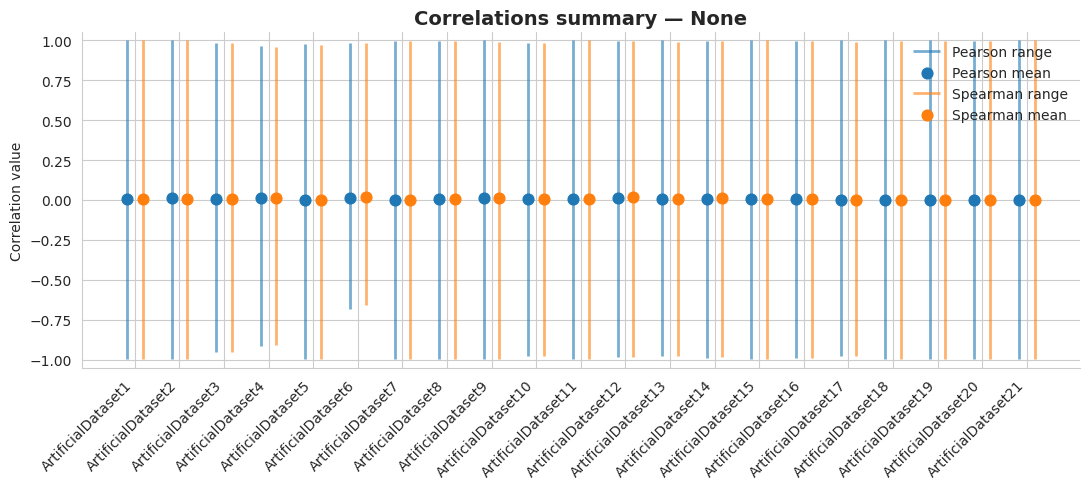

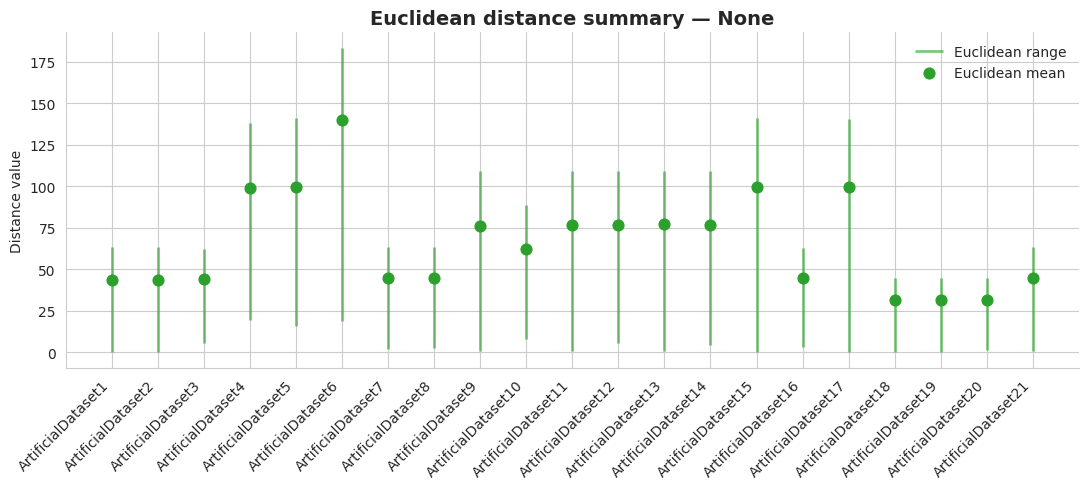

In [15]:
plot_summary_correlations(summary_df_original)

In [16]:
# Cogemos del 1 al 10 porque el resto ya son muchas variables
datasets_subset = dict(list(dataset_files.items())[:20])
# datasets_subset

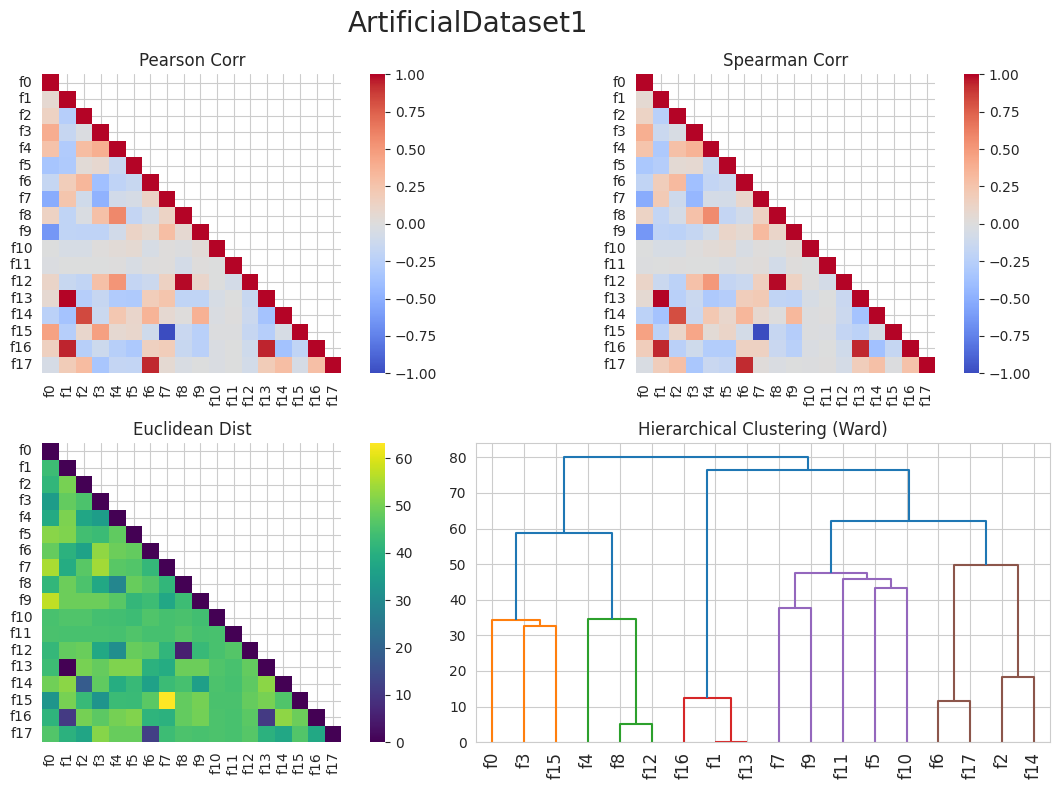

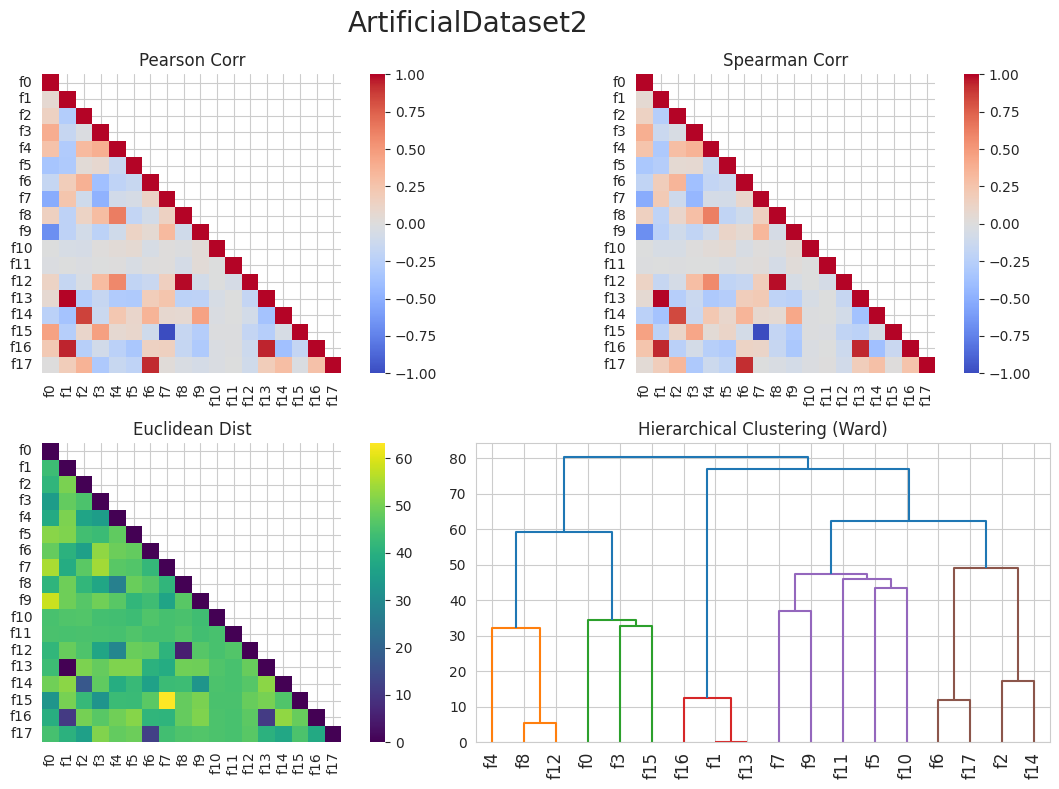

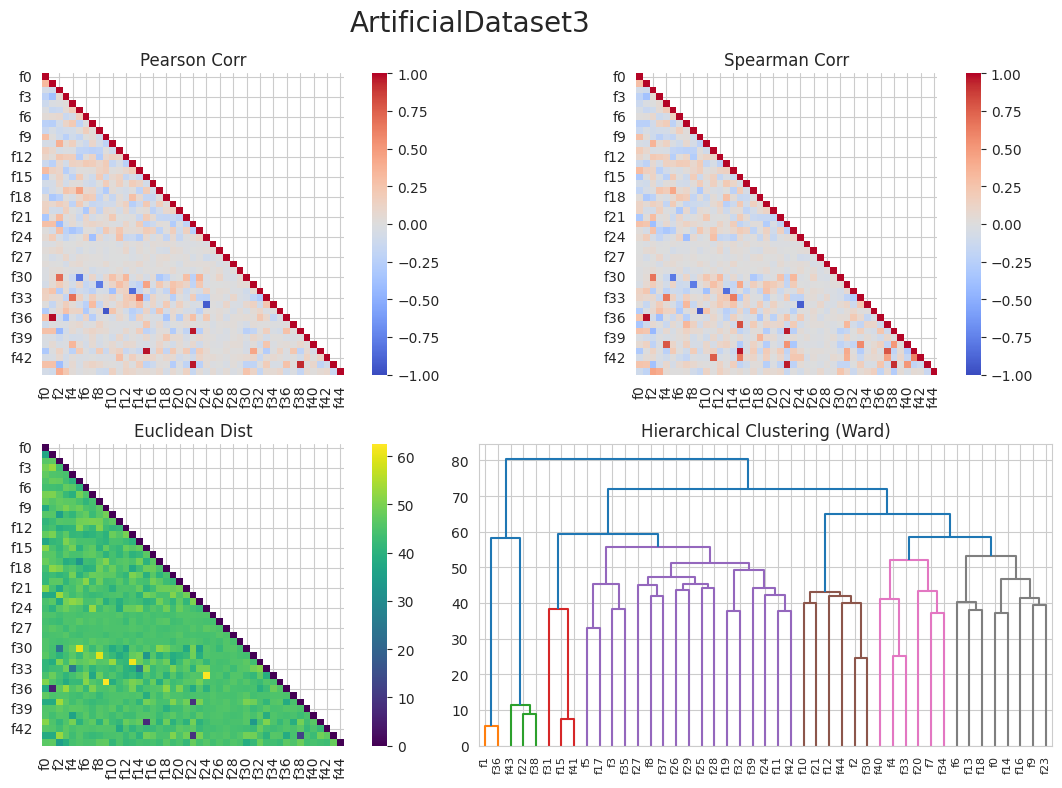

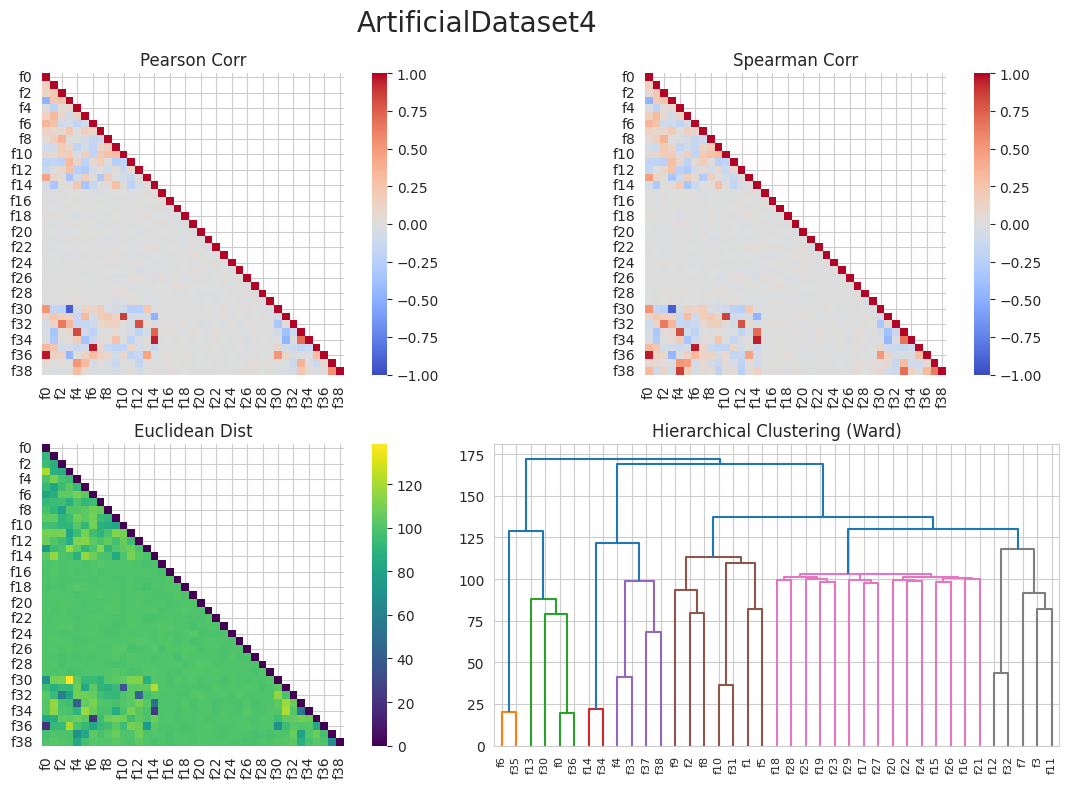

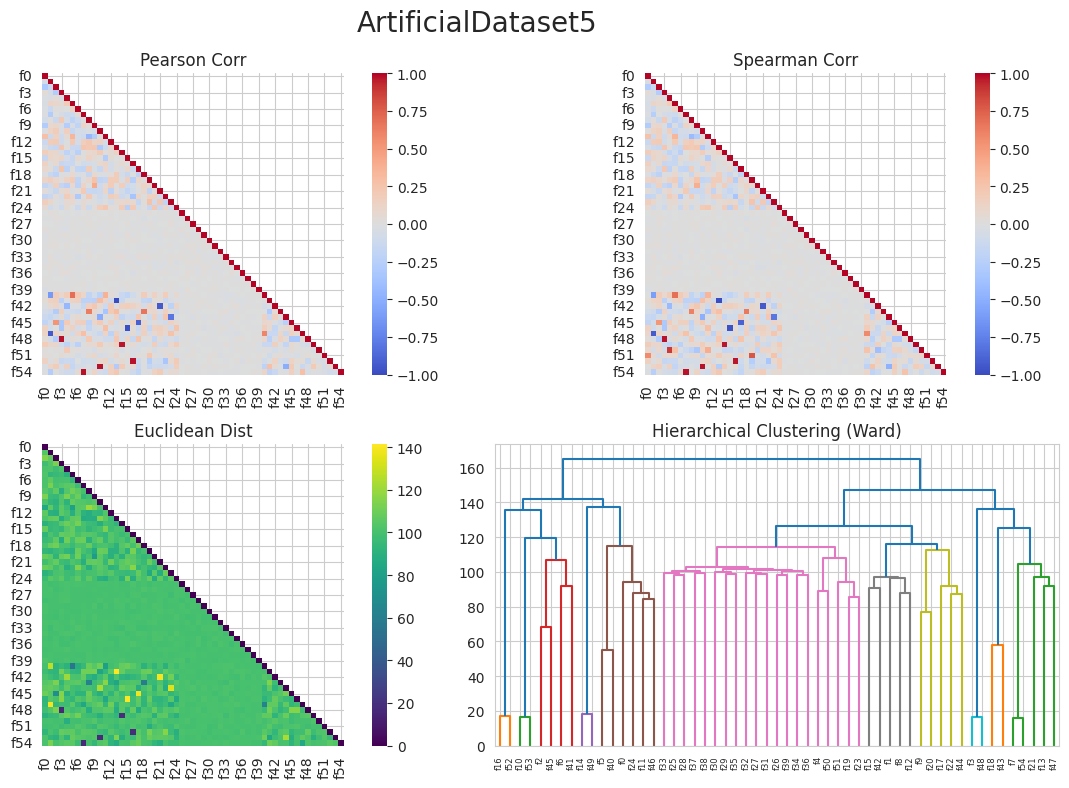

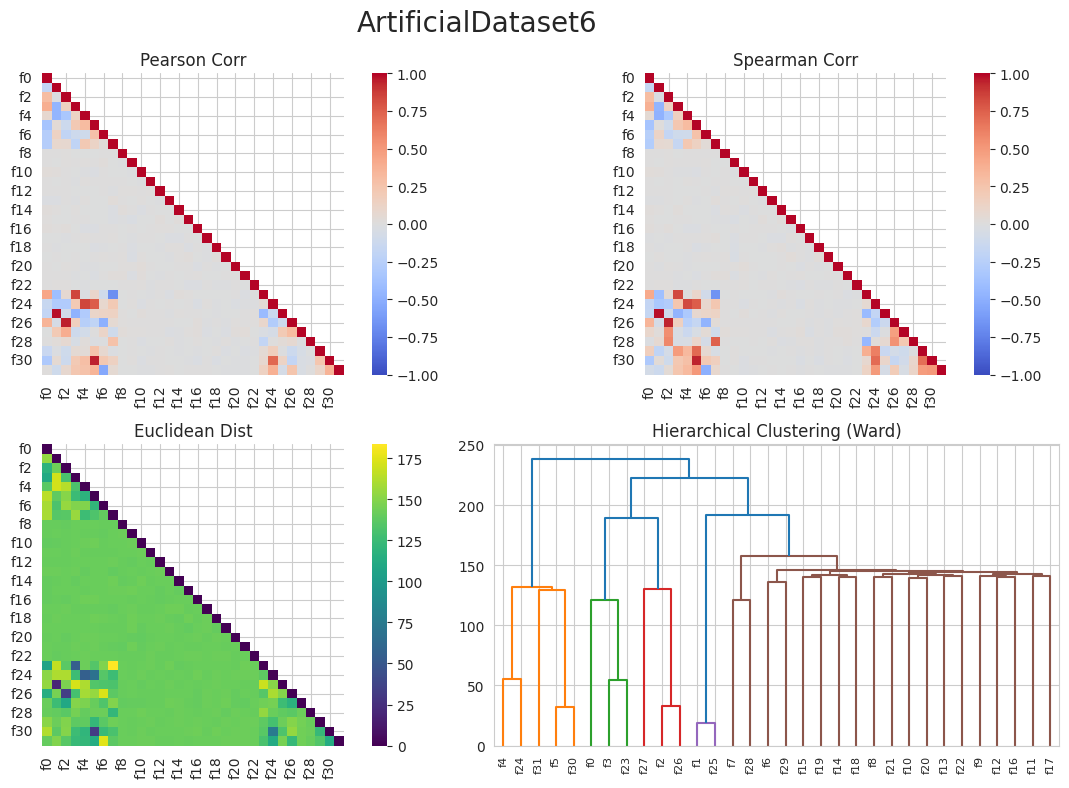

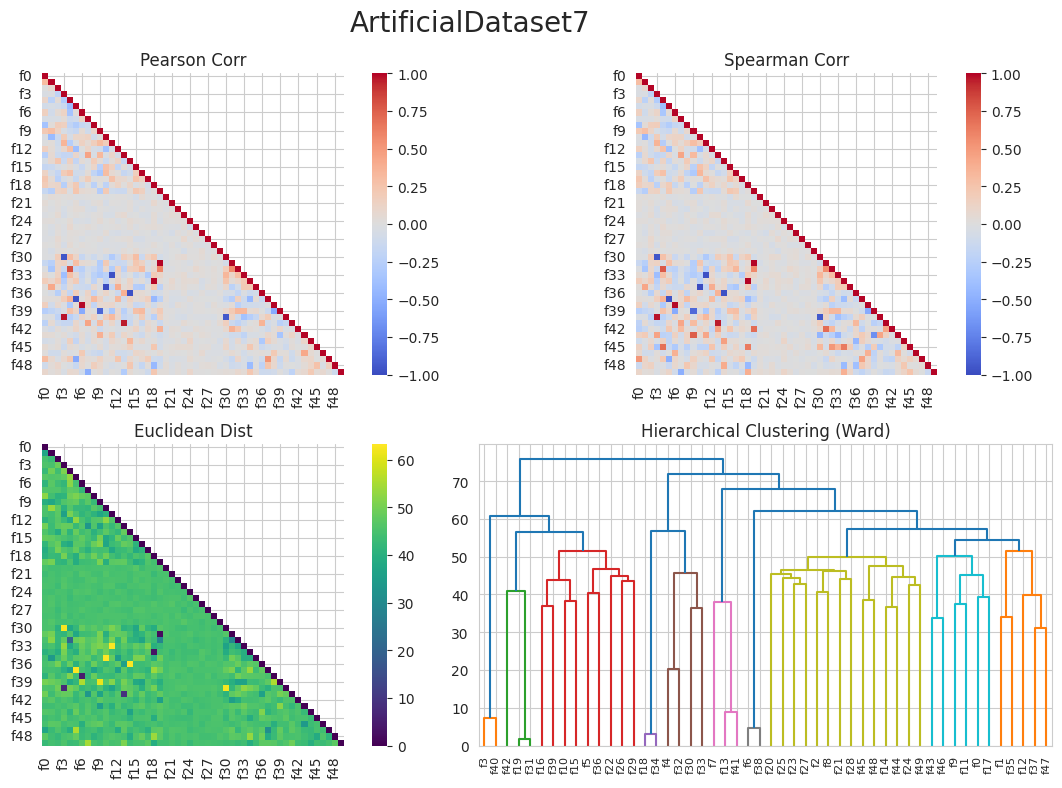

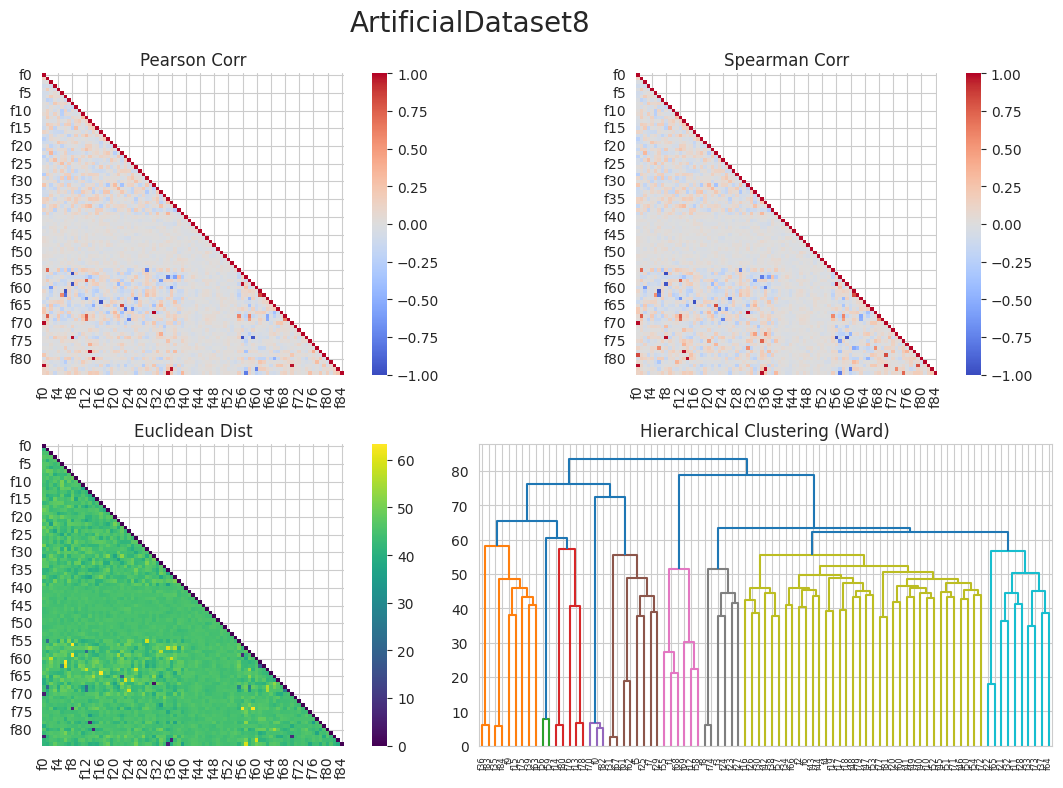

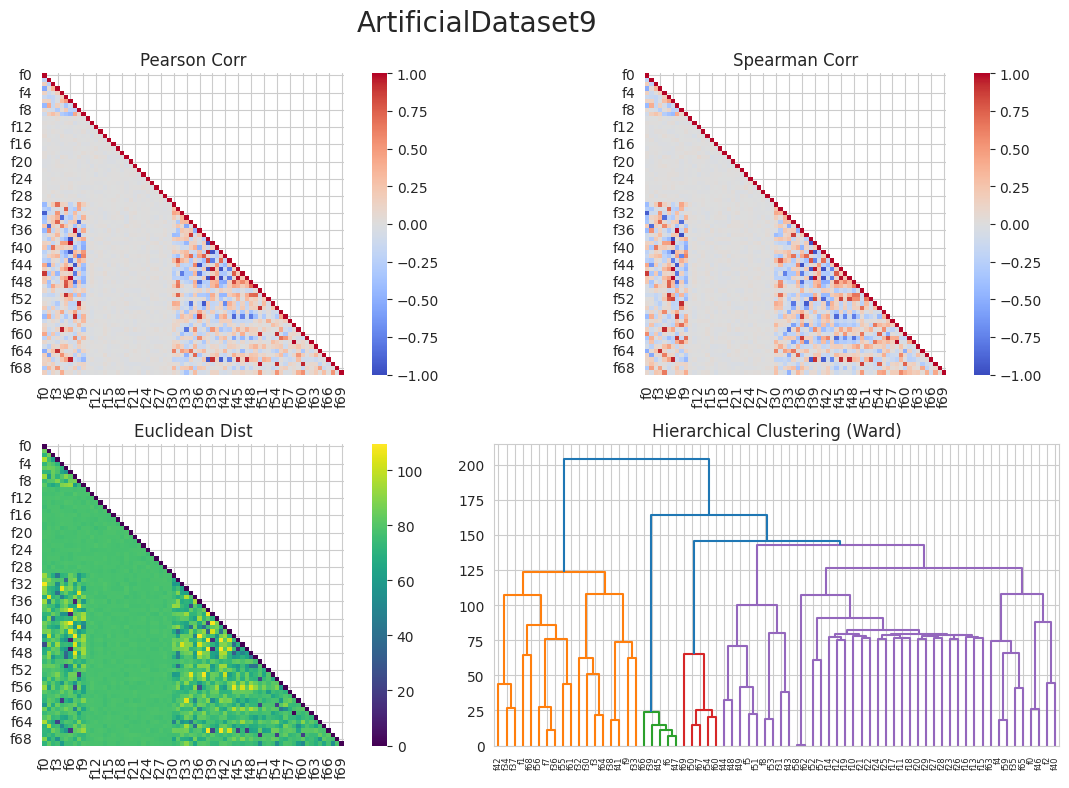

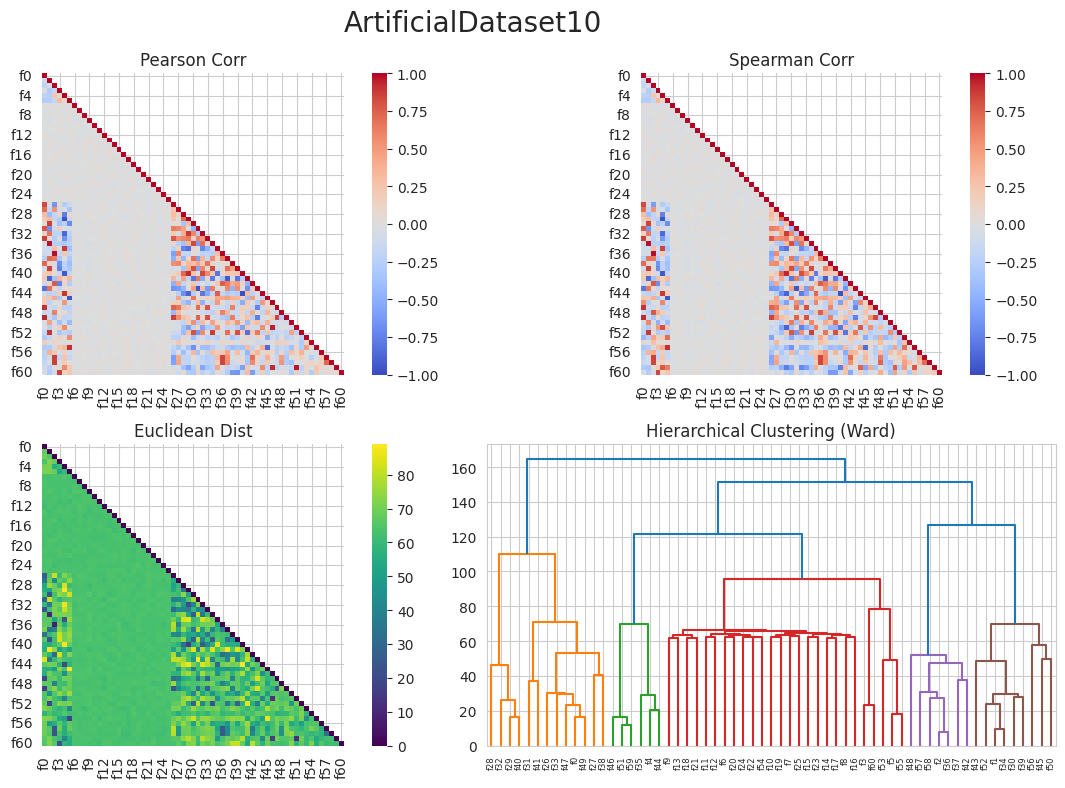

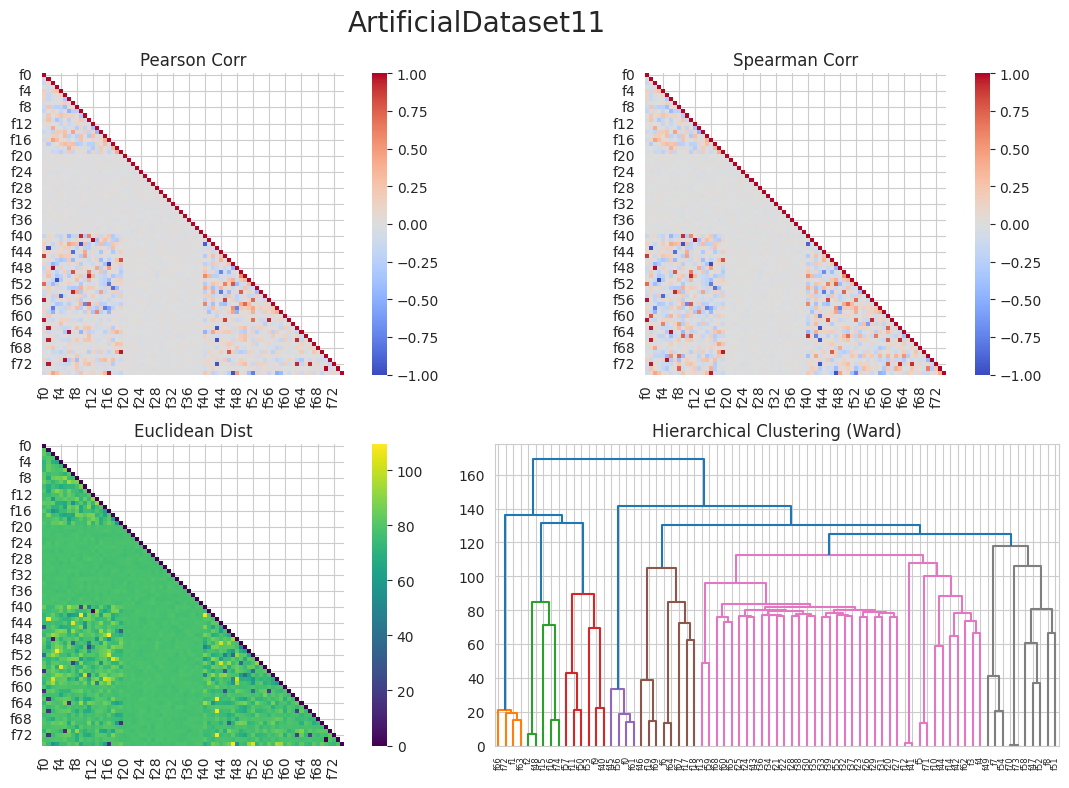

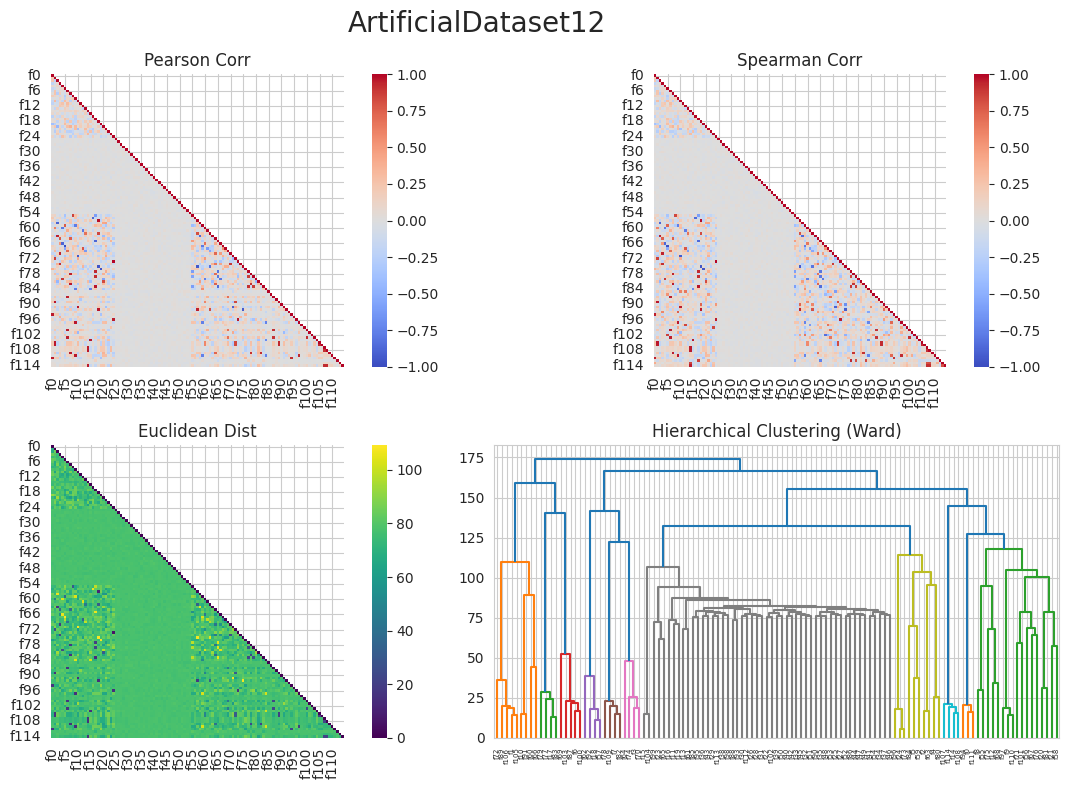

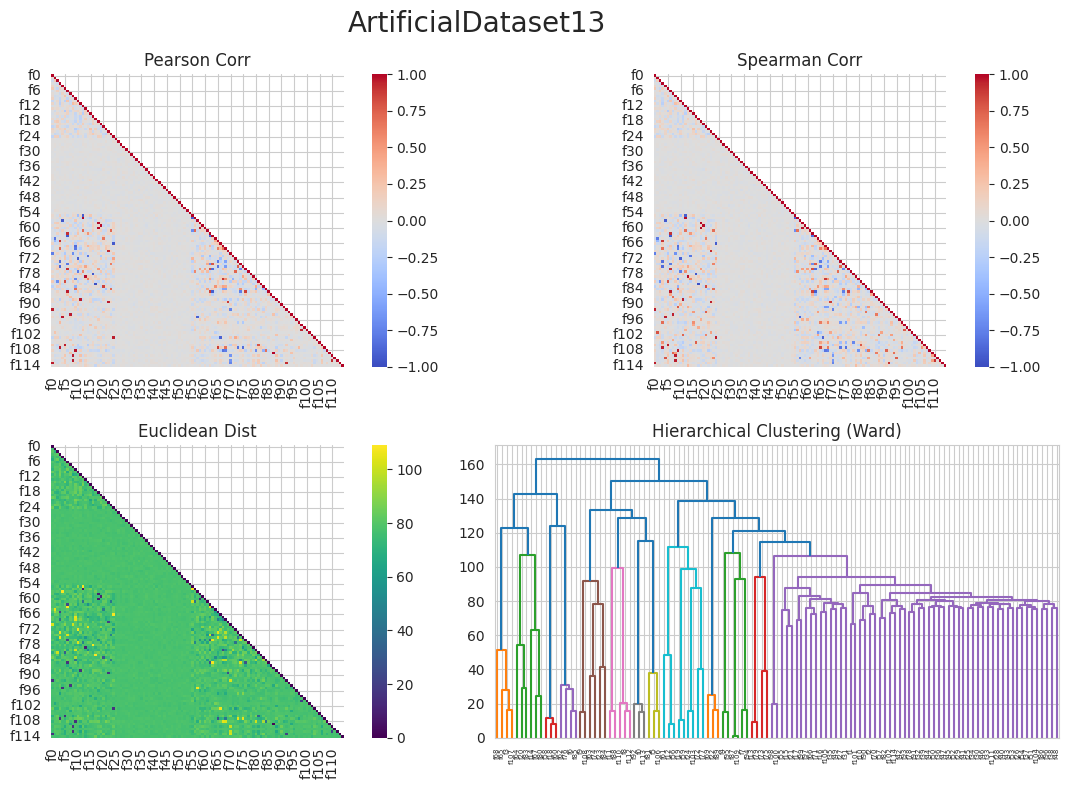

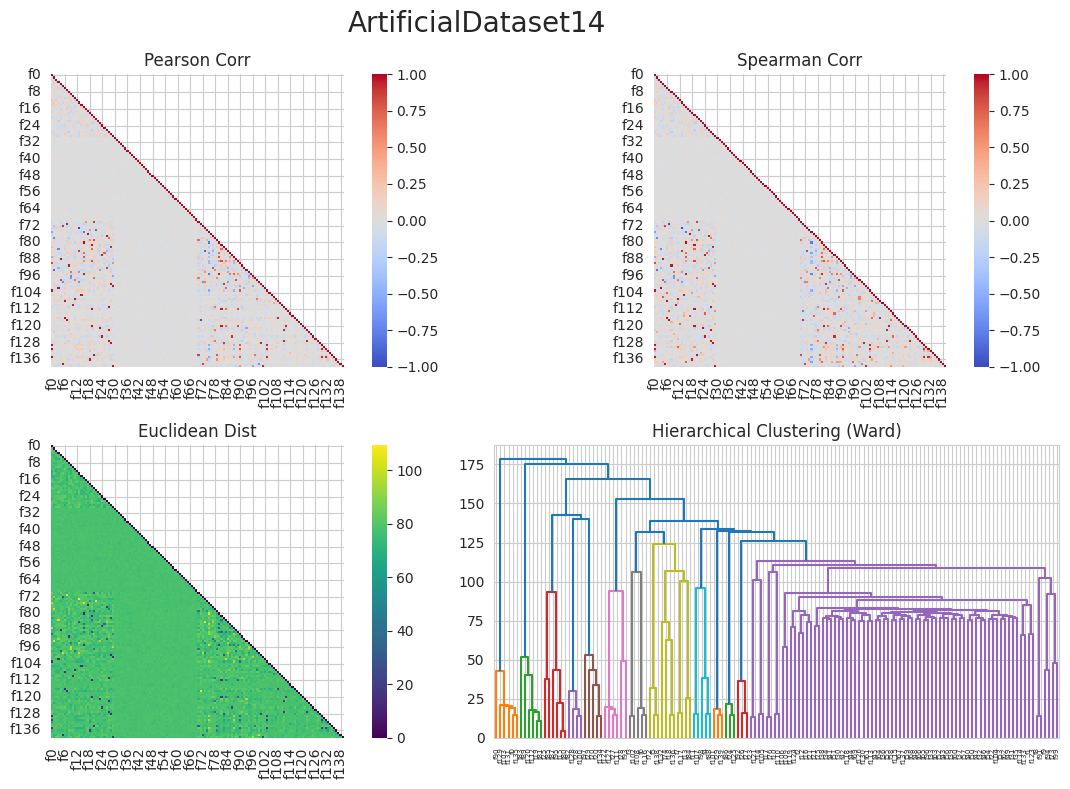

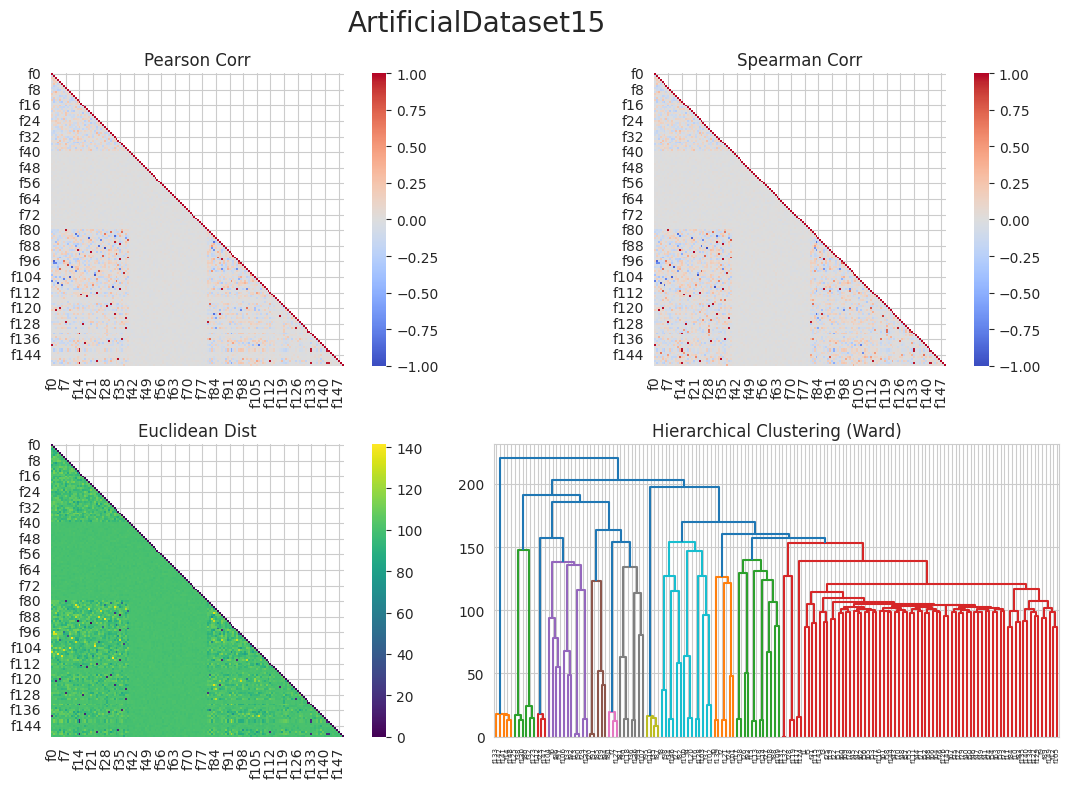

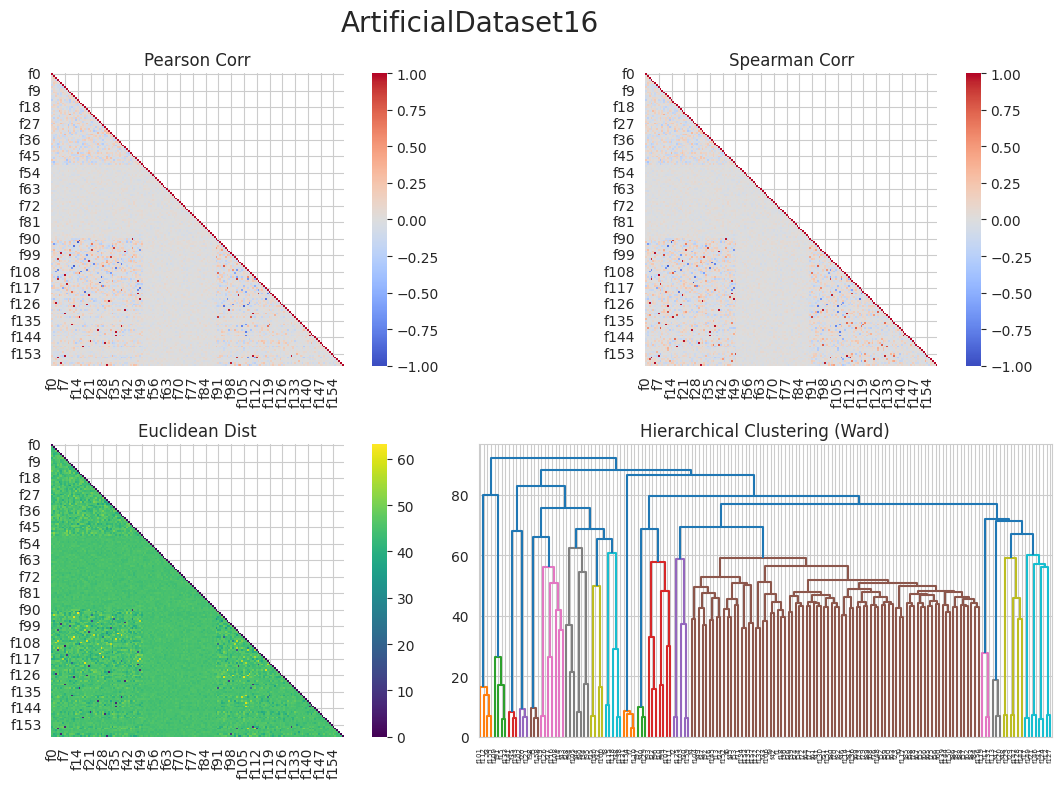

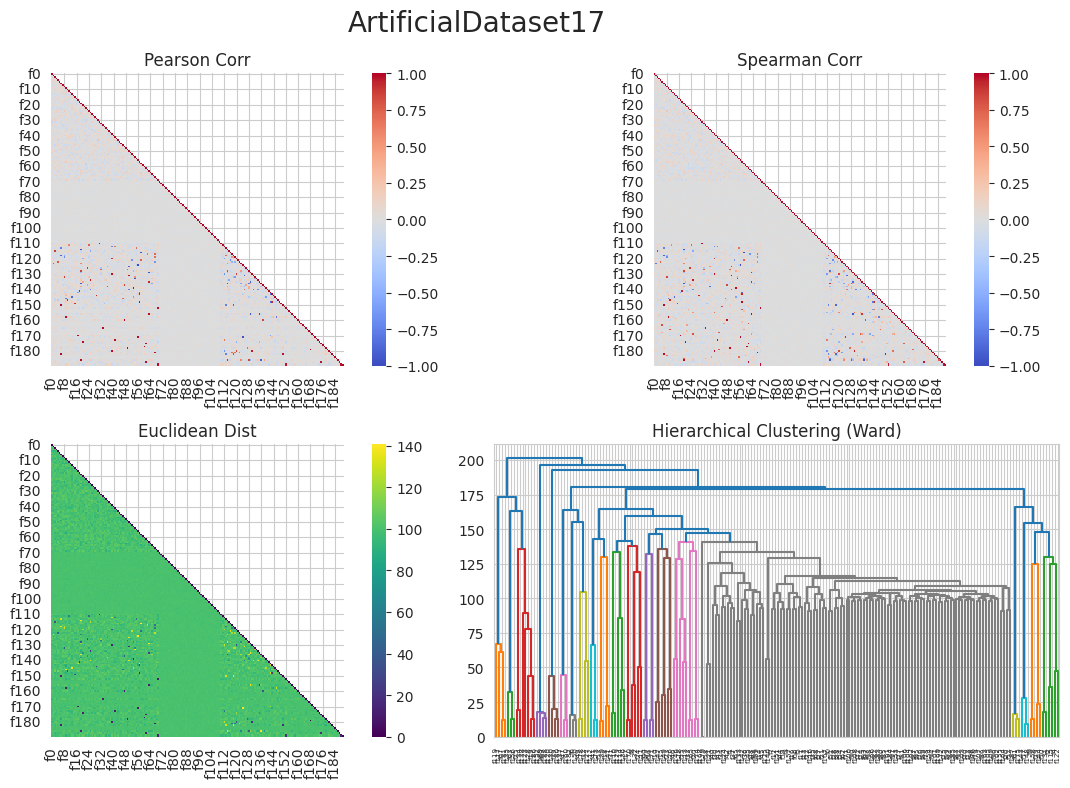

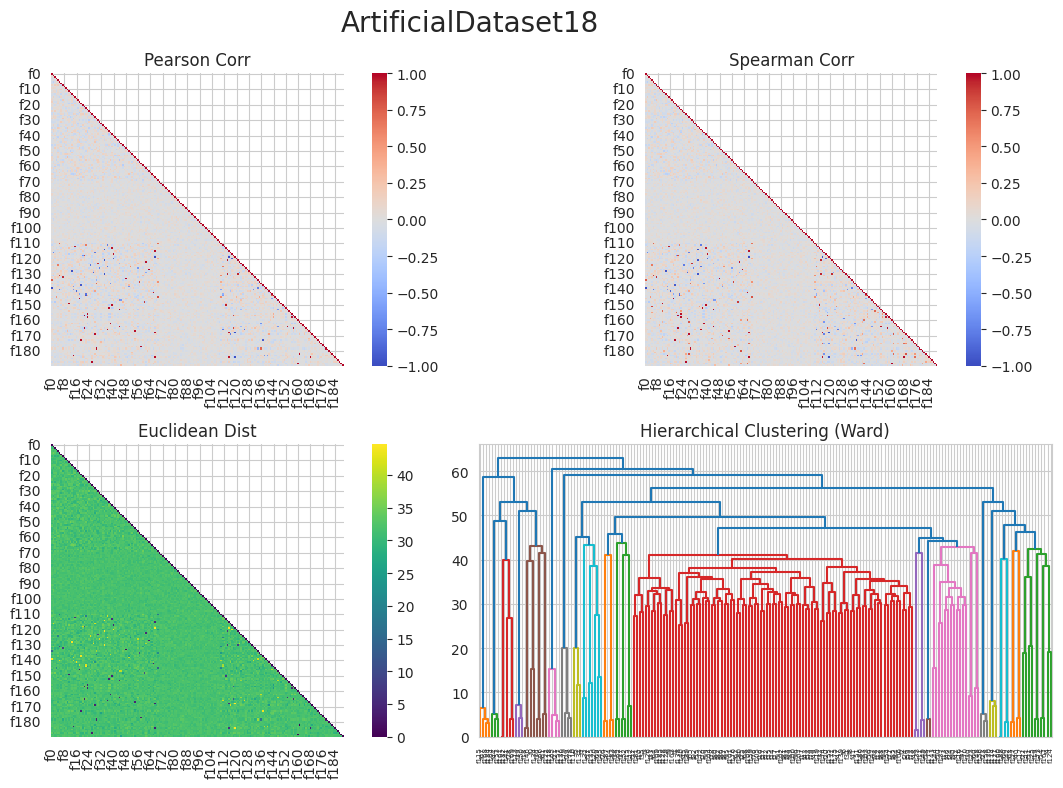

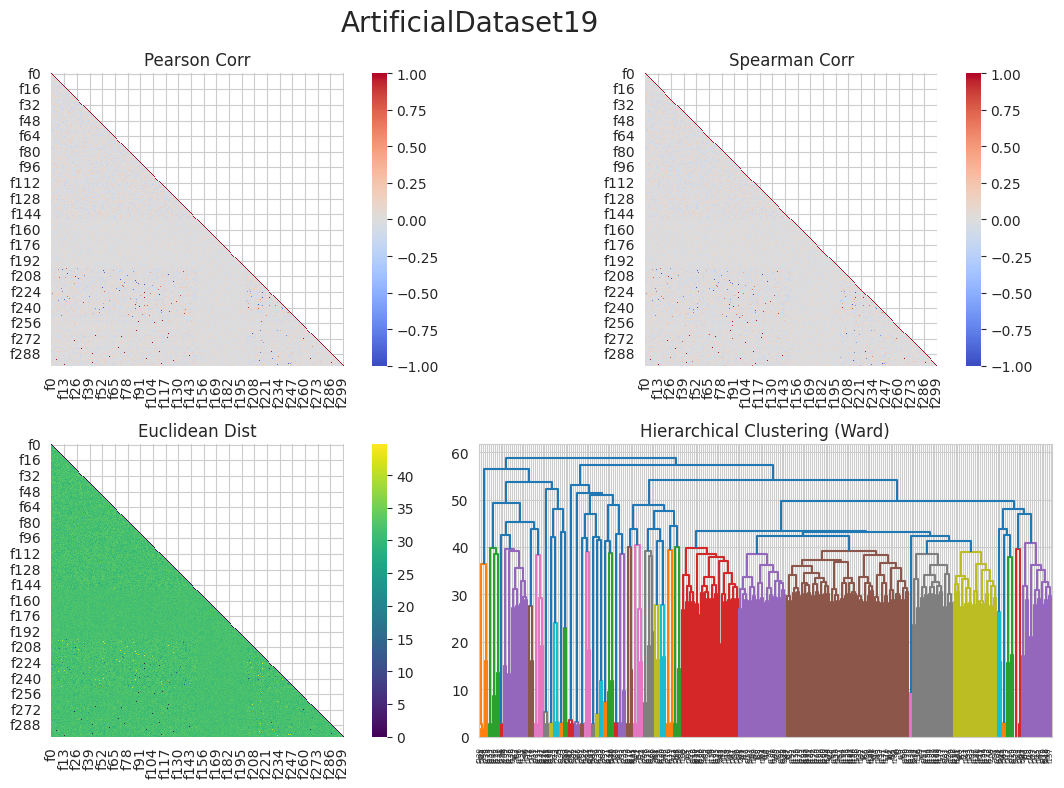

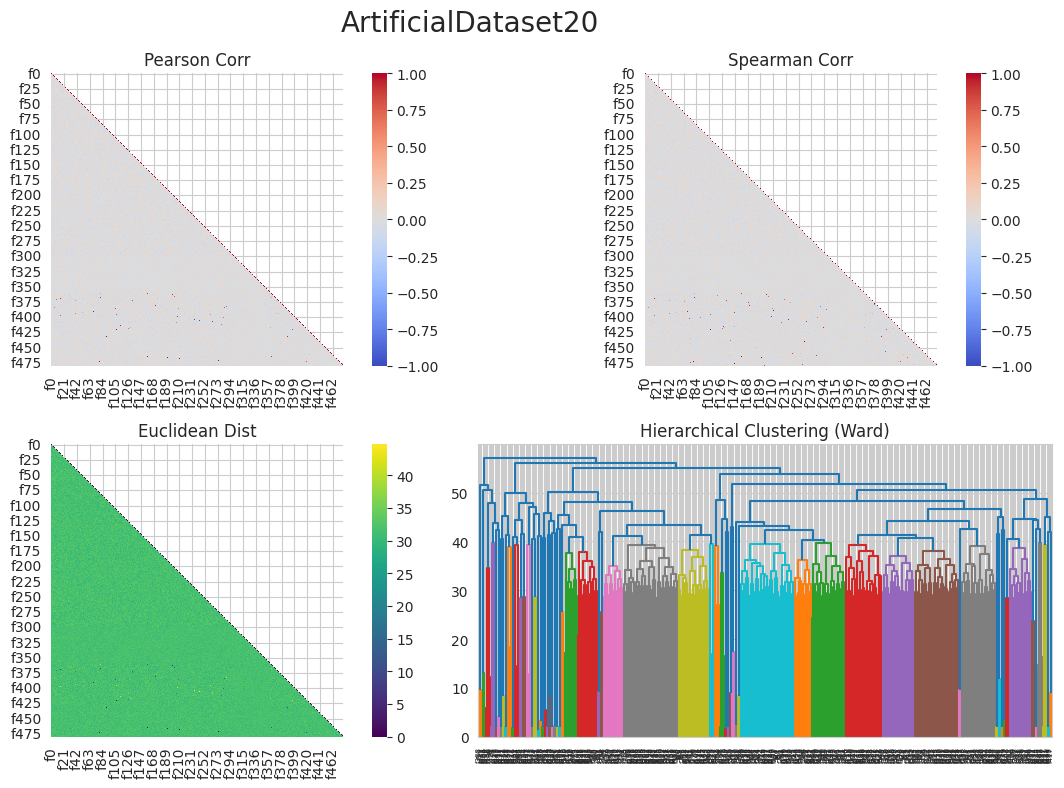

,dataset,measure,pearson_max,pearson_min,pearson_mean,pearson_median,pearson_std,spearman_max,spearman_min,spearman_mean,spearman_median,spearman_std,euclid_max,euclid_min,euclid_mean,euclid_median,euclid_std
0,ArtificialDataset1,None,0.999991,-0.997168,0.007381,-0.013918,0.290185,0.999982,-0.996451,0.007100,-0.010542,0.284636,63.200762,0.131091,43.720975,45.031502,8.585733
1,ArtificialDataset2,None,0.999991,-0.997168,0.009291,-0.019874,0.295515,0.999982,-0.996451,0.008905,-0.012212,0.290010,63.200762,0.131091,43.656523,45.163580,8.690588
2,ArtificialDataset3,None,0.984773,-0.951470,0.003986,0.004730,0.160615,0.982537,-0.949665,0.008127,0.001793,0.174246,62.473517,5.518525,44.439290,44.615473,4.144567
3,ArtificialDataset4,None,0.961605,-0.915357,0.011260,-0.000240,0.145122,0.955636,-0.909695,0.014177,0.000775,0.150896,138.396423,19.594645,99.032411,100.012022,8.943489
4,ArtificialDataset5,None,0.975451,-0.997468,-0.000627,0.000381,0.131850,0.972796,-0.997137,0.000425,0.000446,0.135828,141.331820,15.668091,99.742374,99.980932,7.598257
5,ArtificialDataset6,None,0.982323,-0.684879,0.011790,-0.000305,0.150224,0.980542,-0.660205,0.021113,0.000150,0.172241,183.569017,18.802497,139.925069,141.442890,13.607763
6,ArtificialDataset7,None,0.998407,-0.995998,-0.000134,-0.000224,0.159257,0.998122,-0.995862,0.002448,-0.001088,0.174587,63.182243,1.784848,44.536051,44.726370,4.099770
7,ArtificialDataset8,None,0.996683,-0.999454,0.003146,0.002423,0.128262,0.996185,-0.999342,0.005339,0.001683,0.134124,63.236923,2.575817,44.525007,44.667139,3.351477
8,ArtificialDataset9,None,0.999957,-0.996144,0.013247,0.001524,0.220385,0.991763,-0.995379,0.012832,0.001312,0.234223,109.438857,0.505800,76.288980,77.400628,10.025492
9,ArtificialDataset10,None,0.984098,-0.978140,0.007513,-0.001676,0.247856,0.981819,-0.974949,0.008998,-0.001104,0.259807,88.952564,7.975506,62.344042,63.298523,9.119594


In [17]:
analyze_variable_relationships_original_datasets(datasets_subset, show_plots=True)

Con las variables originales vemos que toda la información sale bastante más clara (en general):
- Las correlaciones quedan mucho más claras, se aprecian azules y rojos más fuertes a simple vista. Además, también hemos visto que los rangos de correlación van en todos los casos de prácticamente -1 a prácticamente 1, esto es algo que con las complejidades no pasa.
- En distancia euclídea también se detectan grupos de variables con poca distancia y grupos con más distancia (al igual que en la correlación, van de la mano). Un poco en línea con la hostilidad (con respecto a claridad de colores, no he analizado aún cómo de pareja es la información) y mucho más claro que N1 y kDN.
- Los clusters son lo menos claro. Sí hay veces que se forman estructuras más definidas pero otras veces vemos que se juntan muchas variables en alturas similares y la estructura clara no es evidente.

Vamos a estudiar en un par de datasets cuál es la relación entre las complejidades a nivel instancia calculadas univariantemente de variables que son combinación de otras. Tipo: x1 y 2x1.

In [18]:
X1, y1, relaciones = generate_synthetic_dataset(n_samples=1000,n_informative=10,n_noise=2,
                                         n_redundant_linear=4,n_redundant_nonlinear=2,
                                        flip_y=0, class_sep = 1, n_clusters_per_class=1 , weights=[0.5],
                                                     random_state=0,noise_std=0.01)
relaciones

{'informative': ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9'],
 'noise': ['f10', 'f11'],
 'redundant_linear': ['f12', 'f13', 'f14', 'f15'],
 'redundant_nonlinear': ['f16', 'f17'],
 'formulas_linear': {'f12': '-0.25*f2 + 1.57*f8 + ruido',
  'f13': '-0.01*f4 + 1.71*f1 + ruido',
  'f14': '1.86*f2 + 1.19*f9 + ruido',
  'f15': '-0.11*f0 + -1.10*f7 + ruido'},
 'formulas_nonlinear': {'f16': 'sin(f0) + f1 + ruido',
  'f17': 'sin(f0) + f6 + ruido'}}

In [62]:
X1['f18'] = np.sin(X1['f0'])
X1['f18'] = StandardScaler(with_mean=True, with_std=True).fit_transform(X1[['f18']])
# Tb he probado con X1['f18'] = X1['f0']

In [63]:
X1

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18
0,-0.104167,-1.706908,1.062966,2.319434,1.371734,2.146754,-0.567018,0.136562,0.526954,0.500062,0.377936,1.208772,0.342072,-1.714046,1.286692,-0.139938,-1.296853,-0.223060,-0.140547
1,-0.783412,-1.456252,1.571056,-0.037189,0.257528,0.685708,0.703724,0.287826,0.018748,0.397145,-0.803399,-1.625134,-0.239156,-1.455843,1.717170,-0.229336,-1.601102,0.381507,-1.044757
2,0.713838,-1.127212,-0.169650,0.915675,1.438142,-0.329156,-2.251517,0.837640,0.746312,-0.464738,1.269375,-0.650232,0.761309,-1.128997,-0.422808,-0.930946,-0.743898,-1.809837,0.999581
3,-0.232365,-0.790219,0.719487,-1.265303,-1.397437,0.359585,0.803794,-0.785926,-1.652711,-0.836751,-0.766852,0.333081,-1.736929,-0.793366,0.215427,0.840372,-0.530597,0.985017,-0.330340
4,-0.437210,2.294610,-0.486779,-1.034780,-0.043697,-1.885845,0.092432,0.905457,-0.924670,-0.515316,-0.199761,1.473008,-0.825314,2.291607,-0.752336,-0.904258,2.163364,0.132442,-0.620564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.372508,0.263477,-0.655302,0.561288,0.374562,-0.841347,-0.633544,0.509872,0.670756,1.346427,0.025281,0.423416,0.767044,0.261006,0.135469,-0.504363,0.331975,-0.491886,-0.531210
996,-0.671023,0.067090,-2.761812,-1.076385,-1.128621,-0.293104,0.287213,0.209298,-0.297700,0.258455,-0.990983,2.207365,0.163661,0.067916,-2.479094,-0.162565,-0.086537,0.097776,-0.918660
997,-0.491008,-0.031350,-0.200159,1.050971,-0.041525,0.417396,-0.322202,-0.439507,0.066271,0.784340,-0.844765,-0.118123,0.098794,-0.033478,0.251216,0.502665,-0.036509,-0.310702,-0.692845
998,-0.137274,0.609982,0.134976,0.117908,0.373481,-1.728925,-0.202256,0.205873,1.066577,2.116478,-0.818951,-1.987346,1.026719,0.610470,1.320841,-0.203725,0.828008,0.095784,-0.189932


In [64]:
datos1_0 = pd.concat([X1['f0'], pd.Series(y1, name="y")], axis=1)
datos1_18 = pd.concat([X1['f18'], pd.Series(y1, name="y")], axis=1)

In [65]:
df_measures1_0, df_classes1_0, _ = all_measures_FS(datos1_0, save_csv=False, path_to_save=None, name_data=None)
df_measures1_18, df_classes1_18, _ = all_measures_FS(datos1_18, save_csv=False, path_to_save=None, name_data=None)

In [66]:
df_classes1_0

,Hostility,kDN,N1
y,,,
0,0.478,0.5092,0.4850
1,0.436,0.4956,0.4860
dataset,0.457,0.5024,0.4855


In [67]:
df_classes1_18

,Hostility,kDN,N1
y,,,
0,0.31,0.5052,0.4870
1,0.39,0.5020,0.4880
dataset,0.35,0.5036,0.4875


In [68]:
pd.concat([df_measures1_0,df_measures1_18],axis=1)

,Hostility,kDN,N1,y,Hostility,kDN,N1,y
0,0.692308,0.6,0.5,0,0.613574,0.6,0.5,0
1,0.666667,0.8,1.0,0,0.659978,0.8,1.0,0
2,0.142857,0.2,0.0,0,0.350466,0.2,0.0,0
3,0.200000,0.4,0.0,0,0.308019,0.4,0.0,0
4,0.600000,0.6,0.5,0,0.577625,0.6,0.5,0
...,...,...,...,...,...,...,...,...
995,0.500000,0.4,0.0,1,0.455708,0.4,0.0,1
996,0.444444,0.8,1.0,1,0.474638,0.8,1.0,1
997,0.416667,0.2,0.5,1,0.347964,0.2,0.5,1
998,0.200000,0.2,0.0,1,0.280504,0.2,0.0,1


In [69]:
df_measures1_0.equals(df_measures1_18)

False

In [74]:
print(df_measures1_0['Hostility'].equals(df_measures1_18['Hostility']))
print(df_measures1_0['kDN'].equals(df_measures1_18['kDN']))
print(df_measures1_0['N1'].equals(df_measures1_18['N1']))

False
False
False


In [73]:
df_measures1_0['N1'].equals(df_measures1_18['N1'])

False

In [78]:
pd.concat([df_measures1_0['N1'], df_measures1_18['N1']], axis=1).corr()

,N1,N1
N1,1.000000,0.832082
N1,0.832082,1.000000


In [79]:
pd.concat([df_measures1_0['Hostility'], df_measures1_18['Hostility']], axis=1).corr()

,Hostility,Hostility
Hostility,1.000000,0.540467
Hostility,0.540467,1.000000


In [80]:
pd.concat([df_measures1_0['kDN'], df_measures1_18['kDN']], axis=1).corr()

,kDN,kDN
kDN,1.000000,0.848074
kDN,0.848074,1.000000


Hemos estudiado los valores de complejidad (a nivel instancia) otorgados univariantemente por variables relacionadas entre sí de dos maneras:

- Relación lineal tipo: x2=a*x1. La complejidad a nivel instancia es exactamente la misma
- Relación no lineal tipo: x2=sin(x1). La complejidad no es igual. En el caso de kDN y N1 presentan una correlación lineal >0.8 pero en el caso de Hostility un valor cercano a 0.5.

¡OJO! Estos resultados los hemos obtenido con un únic ejemplo.